# <font color='orange'>TME ROBOTIQUE ET APPRENTISSAGE</font>
# <font color='orange'>2. Robotique Evolutionnaire</font>

# <font color="green">Version ETUDIANTS·ES 2025-2026</font>

*contact: NB@SU*

*mise à jour: 16/3/2026*


Ce notebook doit être exécuté dans [Google Colab](colab.research.google.com/) ou dans Jupyter.

A la fin du TME, vous devez déposer votre travail sur Moodle:
* déposer votre notebook, avec le nom de fichier *obligatoirement* au format suivant: **RA_NOM1_NOM2.ipynb**
* toutes les cellules doivent être exécutées avec les graphes visibles
* un **bref** commentaire lorsque c'est demandé. Pour toutes les questions, une à deux phrases suffisent

*Le sujet est à faire en binome.*

# COMPLETEZ LES CHAMPS CI-DESSOUS AVEC NOM/PRENOM/CARTE_ETU:

* Étudiant 1: **Oundjian Milos 21500050**
* Étudiant 2: **Antipin Vladislav 21242244**

# Simple Robot Simulator



*   simulate renvoie des stats sur le comportement du robot
  * distance parcourue a chaque pas
  * exploration grille (si utilise trace systématiquement)
*   ...



---
---
---

# <font color='orange'>PREAMBULE: initialisation</font>

# Simulateur robot

Il n'est pas nécessaire de regarder le code de ces cellules, elles sont utiles pour les fonctions utilisées dans les parties suivantes.

Remarque: *il suffit d'exécuter ces cellules une seule fois par instance de noyau.*

In [1]:
from datetime import datetime
from datetime import date
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.cm as cm
import numpy as np
import math
import random
import sys

# !pip install cma
import cma

#### #### ####

print(
    "\n", date.today(), datetime.now().strftime("%H:%M:%S"), "GMT"
)  # timestamp is greenwich time
print("OK.")


 2026-03-19 17:47:52 GMT
OK.


In [2]:
#############################
### 0. Experimental setup ###
#############################

max_iterations = 5001

absolute_orientation = 0  # -90  # degrees
translation_per_step = 1.0  # 1.0 # 6.0  # in [0,1]
max_translation_per_step = 1.0  # >0. pixel per move.
rotation_per_step = 0.0  # in [-1,1]
max_rotation_per_step = 3.0  # >0, in degrees

arena_size = 100  # 50
sensor_length = 10
nb_sensors = 8

particle_box = 3  # bounding box (square)

particle = np.zeros((particle_box, particle_box), dtype=int)

# Drawing a circle in the particle array
# particle_radius_real = particle_box / 2 - 0.5  # Radius of the circle in the particle
# center_particle_real = (particle_box / 2 - 0.5, particle_box / 2 - 0.5)  # Real center of the particle
particle_radius_real = particle_box / 2.0  # Radius of the circle in the particle
center_particle_real = (
    particle_box / 2 - 0.5,
    particle_box / 2 - 0.5,
)  # Real center of the particle

####################
### 1. Structure ###
####################


def init():  # perform only once
    global particle, center_particle_real, particle_radius_real

    for i in range(particle.shape[0]):
        for j in range(particle.shape[1]):
            # Check if the cell falls within the circle radius
            if (
                (i - center_particle_real[0]) ** 2 + (j - center_particle_real[1]) ** 2
            ) <= particle_radius_real**2:
                particle[i, j] = 2
            else:
                particle[i, j] = 3

    init_arena()
    init_trace()


def init_arena():
    global arena
    arena = np.zeros((arena_size, arena_size), dtype=int)


def init_trace():
    global trace
    trace = np.zeros((arena_size, arena_size), dtype=int)


def clear_arena():  # clear content, except for wall
    global arena
    # arena[:] = 0
    arena[arena != 1] = 0


def clear_trace():  # clear content, except for wall
    global trace
    # trace[:] = 0
    trace[trace != 1] = 0


def draw_line(x1, y1, x2, y2, color):  # do not draw on wall
    global arena
    num_points = max(abs(x2 - x1), abs(y2 - y1)) + 1
    x_points = np.linspace(x1, x2, num_points, dtype=int)
    y_points = np.linspace(y1, y2, num_points, dtype=int)
    # shorte, not border-protected:
    # arena[y_points, x_points] = color
    # longer, border-protected:
    for i in range(len(x_points)):
        if (
            y_points[i] >= 0
            and y_points[i] < arena.shape[0]
            and x_points[i] >= 0
            and x_points[i] < arena.shape[1]
        ):
            if arena[y_points[i], x_points[i]] != 1:
                arena[y_points[i], x_points[i]] = color


def cast_sensor(x1, y1, x2, y2, color=6):
    global arena, display_cast
    num_points = max(abs(x2 - x1), abs(y2 - y1)) + 1
    x_points = np.linspace(x1, x2, num_points, dtype=int)
    y_points = np.linspace(y1, y2, num_points, dtype=int)
    max_distance = (
        math.sqrt((x_points[0] - x_points[-1]) ** 2 + (y_points[0] - y_points[-1]) ** 2)
        - particle_radius_real
    )
    for i in range(len(x_points)):
        if (
            y_points[i] >= 0
            and y_points[i] < arena.shape[0]
            and x_points[i] >= 0
            and x_points[i] < arena.shape[1]
        ):
            if (
                arena[y_points[i], x_points[i]] == 1
                or arena[y_points[i], x_points[i]] == 2
                or arena[y_points[i], x_points[i]] == 4
            ):
                if verbose:
                    print("DETECT OBJECT at", i)
                return (
                    math.sqrt(
                        (x_points[0] - x_points[i]) ** 2
                        + (y_points[0] - y_points[i]) ** 2
                    )
                    - particle_radius_real
                ) / max_distance  # distance to obstacle, normalize in [0,1]
            elif display_cast == True:
                arena[y_points[i], x_points[i]] = color
    return 1.0


absolute_orientation = 0.0  # in degrees
translation_per_step = 0.0  # in units
rotation_per_step = 0.0  # in degrees

############################
### 2. General functions ###
############################


def create_wall(x1, y1, x2, y2):
    arena[max(y1, 0) : min(y2, arena_size), max(x1, 0) : min(x2, arena_size)] = 1
    if display_trace:
        trace[max(y1, 0) : min(y2, arena_size), max(x1, 0) : min(x2, arena_size)] = 1


def get_sensors(x, y, absolute_orientation):  # 8 sensors belt
    global sensor_length, nb_sensors

    source_x, source_y = (
        int(x + particle_radius_real - 1),
        int(y + particle_radius_real - 1),
    )

    sensor_values = []
    for i in range(nb_sensors):
        offset_x = (
            math.cos(math.radians(absolute_orientation + i * 360.0 / nb_sensors))
            * sensor_length
        )
        offset_y = (
            math.sin(math.radians(absolute_orientation + i * 360.0 / nb_sensors))
            * sensor_length
        )
        target_x = int(source_x + offset_x + 0.5)
        target_y = int(source_y - offset_y + 0.5)
        sensor_values.append(
            cast_sensor(int(source_x), int(source_y), target_x, target_y, 6)
        )

    return sensor_values


def clean_sensors(x, y, absolute_orientation):  # 8 sensors belt
    global sensor_length, nb_sensors

    if display_cast == False:
        return

    source_x, source_y = (
        int(x + particle_radius_real - 1),
        int(y + particle_radius_real - 1),
    )

    sensor_length = 10
    nb_sensors = 8

    sensor_values = []
    for i in range(nb_sensors):
        offset_x = (
            math.cos(math.radians(absolute_orientation + i * 360.0 / nb_sensors))
            * sensor_length
        )
        offset_y = (
            math.sin(math.radians(absolute_orientation + i * 360.0 / nb_sensors))
            * sensor_length
        )
        target_x = int(source_x + offset_x + 0.5)
        target_y = int(source_y - offset_y + 0.5)
        draw_line(int(source_x), int(source_y), target_x, target_y, 0)

    return sensor_values


def place_particle(x, y, absolute_orientation):
    global arena, particle
    x, y = int(x), int(y)
    arena_slice = arena[y : y + particle_box, x : x + particle_box]

    # Check for overlap between particle and non-zero cells in the arena
    collision = np.logical_and(arena_slice == 1, particle == 2)
    if np.any(collision):
        collision_array = np.where(collision, 3, particle)
        return collision_array

    # arena_slice[ int(math.cos(absolute_orientation)*particle_box/2) , int(math.sin(absolute_orientation)*particle_box/2) ] = 3 # display particle front
    # arena[y:y+particle_box, x:x+particle_box] += np.where(arena_slice == 0, particle, 0)

    for i in range(particle_box):
        for j in range(particle_box):
            if (
                arena[y + i, x + j] == 0
                or arena[y + i, x + j] == 4
                or arena[y + i, x + j] == 6
            ):
                arena[y + i, x + j] = 2

    trace[int(y + particle_box / 2.0), int(x + particle_box / 2.0)] = 2

    if verbose:
        print("location", x + particle_box / 2.0, y + particle_box / 2.0)
        print("absolute_orientation", absolute_orientation)

    offset_x = math.cos(math.radians(absolute_orientation)) * particle_box / 2.0 * 0.999
    offset_y = math.sin(math.radians(absolute_orientation)) * particle_box / 2.0 * 0.999
    x_head = int(x + particle_box / 2.0 + offset_x)
    y_head = int(y + particle_box / 2.0 - offset_y)
    if verbose:
        print("y_head, x_head", y_head, x_head)

    arena[y_head, x_head] = 4  # Display particle front

    return None


def erase_particle(x, y):
    global arena, particle
    x, y = int(x), int(y)
    # arena[y:y+particle_box, x:x+particle_box] -= particle * (arena[y:y+particle_box, x:x+particle_box] != 0)
    for i in range(particle_box):
        for j in range(particle_box):
            if arena[y + i, x + j] == 2 or arena[y + i, x + j] == 4:
                arena[y + i, x + j] = 0


def draw(arena, double_size=False):

    if double_size == True:
        doubled_figsize = (12.8, 9.6)
        plt.figure(figsize=doubled_figsize)

    cmap = colors.ListedColormap(["white", "black", "grey", "red", "orange", "green"])
    bounds = [0, 1, 2, 3, 4, 5, 6]
    norm = colors.BoundaryNorm(bounds, cmap.N)

    plt.imshow(arena, cmap=cmap, norm=norm)
    plt.colorbar(
        ticks=[0.5, 1.5, 2.5, 3.5, 4.5, 5.5],
        format=plt.FuncFormatter(
            lambda x, _: {
                0.5: "0 - nothing",
                1.5: "1 - obstacle",
                2.5: "2 - robot",
                3.5: "3 - collision",
                4.5: "4 - robot front",
                5.5: "5 - sensor ray",
            }[x]
        ),
    )
    plt.show()


def show_arena():
    draw(arena, double_size=False)


def show_trace():
    draw(trace, double_size=False)


####################################
### 3. PARTICLE UPDATE functions ###
####################################


def update_particle_position(
    x,
    y,
    absolute_orientation,
    translation_per_step,
    rotation_per_step,
    iteration,
    noiseFlag=False,
):
    """
    Function called to update particle position (and orientation). It should merge the desired control command from the user (translation_per_step and rotation_per_step) and the physics of environment and particle.
    Below is a simple example where desired translation and rotation per step are applied directly (ideal: no friction, unbounded bang-bang controller)
    Add whatever you need as persistent internal data.

    # x, y: position of the particle (real values)
    # absolute_orientation: particle absolute orientation wrt an external referential (0° points rightward, trigonometric, use degree)
    # translation_per_step, rotation_per_step: *desired* value by the controller/user. I.e.: values are applied if no friction, no inertia, no collision (see example below)
    # iteration: simulator iteration number (may be ignored)
    """

    new_orientation = absolute_orientation + rotation_per_step

    # Sinusoidal noise for rotation (optional)
    if noiseFlag == True:
        noise = 10 * math.sin(2 * math.pi * iteration / 5)
        new_orientation += noise

    # Convert orientation to radians for calculation
    orientation_radians = math.radians(new_orientation)

    new_x = x + translation_per_step * math.cos(orientation_radians)
    new_y = y - translation_per_step * math.sin(
        orientation_radians
    )  # Minus sign due to y-axis inversion in image coordinates

    return new_x, new_y, new_orientation


def update_particle_dynamics(
    x,
    y,
    absolute_orientation,
    translation_per_step,
    rotation_per_step,
    iteration,
    collision_array,
):
    """
    Function called to udpate internal data (to be defined here) in case of a collision event.
    This function does not move the robot. Updating the absolute_orientation is possible, as well as (to be defined) internal data structure (e.g. encoding the effect of inertia)
    Note that when a particle experience a collision, the collision is recorded (see collision_array) and move is cancelled.
    The goal of this function is to compute/update all necessary information to call later the update_particle_position function.
    Add whatever you need as persistent internal data.

    # x, y: position of the particle (real values)
    # absolute_orientation: particle absolute orientation wrt an external referential (0° points rightward, trigonometric, use degree)
    # translation_per_step, rotation_per_step: *desired* value by the controller/user. I.e.: values are applied if no friction, no inertia, no collision (see example below)
    # iteration: simulator iteration number (may be ignored)
    # iteration: simulator iteration number (may be ignored)
    # collision_array: integer array showing the particle state within its bounding box. 0 for nothing, 1 for particle elements, 2 for particle elements experiencing a collision event

    Testing: essaye avec translation_per_step=1.0, puis avec translation_per_step=6.0 (cas intéressant du a la faible épaisseur du mur)
    """

    # do nothing for now.

    return absolute_orientation


#######################
### 4. Main loop    ###
#######################


# parameters
# initial x and y position and orientation
# step controller function which returns translation/rotation (in [-1,1]) from sensors (in [0,1])
# returns:
# sum of actual translations in [0,1]. Normalized over time and max translation.
# sum of rotation, absolute value normalized value in [0,1]. Normalized over time and max rotation.
# number of pixels of arena visited (unique location, ie. visited twice counts as 1)
# particle's x coordinate at the end
# particle's y coordinate at the end
def simulate(x0, y0, orientation0, step):
    global x_particle, y_particle, absolute_orientation, trace

    clear_arena()
    clear_trace()

    x_particle, y_particle = x0, y0
    absolute_orientation = orientation0
    sensors = get_sensors(x_particle, y_particle, absolute_orientation)
    collision_array = place_particle(x_particle, y_particle, absolute_orientation)

    if collision_array is not None:
        print("[ERROR] initial location triggers collision.")
        sys.exit()

    iteration = 0
    log_sum_of_translation = 0  # logging
    log_sum_of_rotation = 0  # logging

    while iteration < max_iterations:
        if (
            verbose_minimal_progress == True
            and iteration % gap_between_display_minimal_progress == 0
        ):
            print("### iteration", iteration, "/", max_iterations, "###")

        translation_per_step, rotation_per_step = step(sensors)

        log_sum_of_rotation += abs((max(-1.0, min(+1.0, rotation_per_step))))  # logging

        erase_particle(x_particle, y_particle)
        clean_sensors(x_particle, y_particle, absolute_orientation)
        backup_x_particle, backup_y_particle = x_particle, y_particle
        x_particle, y_particle, absolute_orientation = update_particle_position(
            x_particle,
            y_particle,
            absolute_orientation,
            (max(-1.0, min(+1.0, translation_per_step))) * max_translation_per_step,
            (max(-1.0, min(+1.0, rotation_per_step))) * max_rotation_per_step,
            iteration,
            noiseFlag=False,
        )
        sensors = get_sensors(x_particle, y_particle, absolute_orientation)
        collision_array = place_particle(x_particle, y_particle, absolute_orientation)
        if collision_array is not None:  # collision occured
            if verbose == True:
                print("Collision detected!")
            if display_collision:
                print(collision_array)
            clean_sensors(x_particle, y_particle, absolute_orientation)
            x_particle, y_particle = backup_x_particle, backup_y_particle
            sensors = get_sensors(x_particle, y_particle, absolute_orientation)
            if display_collision:
                draw(collision_array)  # Draw the collision array
            absolute_orientation = update_particle_dynamics(
                x_particle,
                y_particle,
                absolute_orientation,
                (max(-1.0, min(+1.0, translation_per_step))) * max_translation_per_step,
                (max(-1.0, min(+1.0, rotation_per_step))) * max_rotation_per_step,
                iteration,
                collision_array,
            )
            place_particle(x_particle, y_particle, absolute_orientation)
            if verbose:
                print("Backtrack")

        if x_particle != backup_x_particle or y_particle != backup_y_particle:
            log_sum_of_translation += math.sqrt(
                (x_particle - backup_x_particle) ** 2
                + (y_particle - backup_y_particle) ** 2
            )  # logging

        if display_arena == True:
            draw(arena)  # Draw the arena at each step
        if verbose == True:
            print(arena)
        iteration = iteration + 1

    log_pixels_visited = np.sum(trace == 2)

    retValues = {
        "translations": log_sum_of_translation / max_iterations,
        "rotations": log_sum_of_rotation / max_iterations,
        "coverage": log_pixels_visited / (arena_size**2),
        "x_pos_end": x_particle,
        "y_pos_end": y_particle,
        "theta_end": absolute_orientation,
    }

    return retValues


#### #### ####

print(
    "\n", date.today(), datetime.now().strftime("%H:%M:%S"), "GMT"
)  # timestamp is greenwich time
print("OK.")


 2026-03-19 17:47:52 GMT
OK.


# Fonctions utiles (construction d'arènes)

Exécutez. Vous pouvez étudier, voire étendre le contenu.

Remarque: create_arena_walls() doit être appelé systématiquement lors de la création d'une nouvelle arène.


In [3]:
def create_arena_walls():  # arena walls are *mandatory* to enclose the robot into a closed arena (otherwise: code will fail with out-of-bounds at some point)
    global arena_size
    create_wall(0, 0, arena_size, 1)
    create_wall(0, arena_size - 1, arena_size, arena_size)
    create_wall(0, 0, 1, arena_size)
    create_wall(arena_size - 1, 0, arena_size, arena_size)


def create_wall_1():
    global arena_size
    create_wall(
        arena_size // 2 + 13,
        arena_size // 2 - 10,
        arena_size // 2 + 16,
        arena_size // 2 + 10,
    )


def create_wall_2(y_shift=0):
    global arena_size
    create_wall(
        arena_size // 2 + 13,
        arena_size // 2 - 10 + y_shift,
        arena_size // 2 + 16,
        arena_size // 2 + 10 + y_shift,
    )
    create_wall(
        arena_size // 2 - 16,
        arena_size // 2 - 10 + y_shift,
        arena_size // 2 - 13,
        arena_size // 2 + 10 + y_shift,
    )
    create_wall(
        arena_size // 2 - 13,
        arena_size // 2 - 10 + y_shift,
        arena_size // 2 + 13,
        arena_size // 2 - 7 + y_shift,
    )
    create_wall(
        arena_size // 2 - 13,
        arena_size // 2 + 7 + y_shift,
        arena_size // 2 - 2,
        arena_size // 2 + 10 + y_shift,
    )
    create_wall(
        arena_size // 2 + 3,
        arena_size // 2 + 7 + y_shift,
        arena_size // 2 + 13,
        arena_size // 2 + 10 + y_shift,
    )


#### #### ####

print(
    "\n", date.today(), datetime.now().strftime("%H:%M:%S"), "GMT"
)  # timestamp is greenwich time
print("OK.")


 2026-03-19 17:47:52 GMT
OK.


# Initialisation des paramètres expérimentaux et des options recommandées d'affichage de messages

In [4]:
# experimental settings

arena_size = 100
max_translation_per_step = 1.0  # >0. pixel per move.
max_rotation_per_step = 10.0  # >0, in degrees
max_iterations = 5001  # nb of simulator iterations for evaluating one robot

# default values for display debug (may be changed later)

verbose_minimal_progress = (
    True  # suggested: True -- useful. Tune gap_between_... to limit the nb of messages
)
gap_between_display_minimal_progress = int(
    max_iterations / 5
)  # used if verbose_minimal_progress = True
verbose = False  # suggested: False -- used for debug
display_collision = False  # suggested: False -- used for debug
display_arena = False  # suggested: False -- if True, display arena for *all* iterations
display_trace = True  # suggested: True
display_cast = False  # suggested: False -- if True, display sensor ray casting for *all* iterations (even w/o display)

#### #### ####

print(
    "\n", date.today(), datetime.now().strftime("%H:%M:%S"), "GMT"
)  # timestamp is greenwich time
print("OK.")


 2026-03-19 17:47:52 GMT
OK.


---
---
---

# <font color="orange">Partie 1. Prise en main : stratégies comportementales</font>

Le robot dispose de 8 senseurs (tous ne seront pas utilisés dans la suite) et de deux commandes motrices (translation et rotation). Toutes les commandes sont normalisées (senseurs dans [0,1], translation et rotation dans [-1,+1]).

Les dimensions du robot sont de 2x2 unités. Une unité correspond à un pixel. Cependant, même si l'affichage est discret, le robot se déplace de manière continue dans l'environnement (position/orientation sont des valeurs réelles). La gestion des collisions est faîtes de manière discrète, les déplacements et la mise à jour des valeurs senseurs est faite sur la base de valeurs continues.

La structure des senseurs est la suivante:
  - [0] avant
  - [1] avant-gauche
  - [2] gauche
  - [3] arrière-gauche
  - [4] arrière
  - [5] arrière-droite
  - [6] droite
  - [7] avant-droite

L'orientation est définie comme suit:
  - *absolute_orientation* est utilisé à l'initialisation pour positionner le robot. la valeur 0 indique que le robot pointe vers la droite de l'arène. =-90 vers le bas. etc. (sens trigonométrique)
  - *rotation* est une commande motrice du robot. Elle s'exprime dans le sens trigonométrique (le robot tourne à gauche si inférieure à 0). Elle est définie entre -1 et +1. Cependant, la rotation effective dépend du paramètre *max_rotation_per_step* (non modifiable), qui donne l'angle de rotation maximum possible entre deux itérations du simulateur.
  - exemple: une rotation de -1.0 sachant que max_rotation_per_step=10 provoque une rotation dans le sens inverse des aiguilles d'une montre de 10° par itération.

La translation est définie comme suit:
  - entre -1 (vitesse max. en arrière) et 1 (vitesse max. en avant). pas de déplacement si la translation vaut 0.
  - la translation effective dépend du paramètre *max_translation_per_step* (non modifiable) qui donne le nombre d'unité de déplacement maximum par itération de l'algorithme.
  - exemple: une translation de -0.5 sachant que max_translation_per_step=10 provoque une translation vers l'arrière de 5 unités par itération.
  - Remarque: la notion d'avant et d'arrière est arbitraire. En pratique, cette asymétrie est une interprétation que nous faisons en observant le comportement. En particulier, le résultat d'une optimisation peut *vous* donner l'*impression* que le robot se déplace en reculant (cf. suite du sujet), mais cette observation n'a pas de sens du point de vue du robot (en particulier si les senseurs sont disposés de manière symétrique, ce qui est le cas ici).

<font color="red">EXERCICES:</font>

- Etudiez et exécutez les trois exemples de stratégies comportementales. Chaque évaluation produit un certain nombre d'informations: des informations quantitatives sur la trajectoire (cf. retour de la fonction) et deux graphes permettant d'observer (a) la trajectoire du robot et (b) sa position/orientation finale.

- Etudiez et exécutez le code de la dernière cellule. Vous observerez qu'en modifiant la valeur de *display_arena* pour la mettre à True, on affichera image par image l'exécution de la simulation. Cela pourra vous être utile par la suite pour comprendre par observation un comportement (n'oubliez pas de remettre la variable à False ensuite, afin de ne pas ralentir inutilement l'exécution du code).

# Un robot peu prudent

#
# Policy no.1 -- dumb robot
#
### iteration 0 / 5001 ###
### iteration 1000 / 5001 ###
### iteration 2000 / 5001 ###
### iteration 3000 / 5001 ###
### iteration 4000 / 5001 ###
### iteration 5000 / 5001 ###

Statistiques:
	 translations      : 0.0023995200959808036
	 rotations         : 0.0
	 couverture        : 0.0013
	 position initiale : ( 48.5 , 48.5 , 0 )
	 position finale   : ( 60.5 , 48.5 , 0.0 )

# Final state


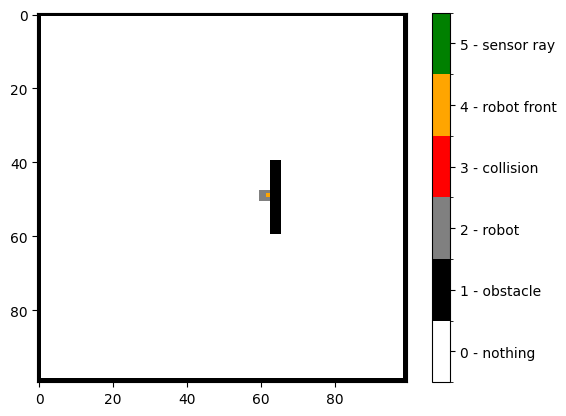

# Trajectory


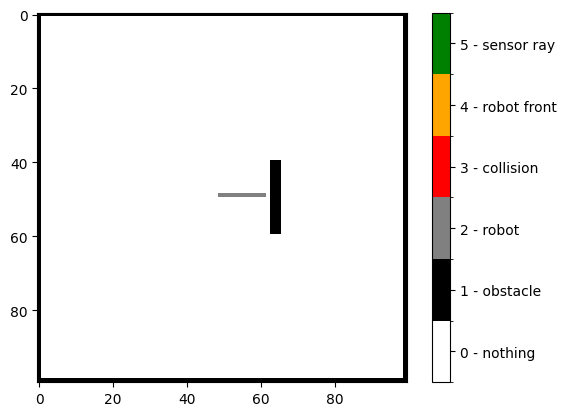

In [5]:
# policy function


def my_controller_dumb(sensors):
    translation = 1.0
    rotation = 0.0
    return translation, rotation


# Main

init()

print("#\n# Policy no.1 -- dumb robot\n#")

display_arena = False  # diplay step-by-step if True.
verbose_minimal_progress = (
    True  # suggested: True -- useful. Tune gap_between_... to limit the nb of messages
)

# clear_arena()
create_arena_walls()
create_wall_1()

x_init = arena_size // 2 - particle_box / 2
y_init = arena_size // 2 - particle_box / 2
theta_init = 0

retValues = simulate(x_init, y_init, theta_init, my_controller_dumb)

print()
print("Statistiques:")
print(
    "\t translations      :", retValues["translations"]
)  # Somme des valeurs absolues de translations. valeurs normalisées entre 0 et 1.
print(
    "\t rotations         :", retValues["rotations"]
)  # Somme des valeurs absolues de rotations. Valeur normalisée entre 0 et 1.
print(
    "\t couverture        :", retValues["coverage"]
)  # taux de couverture. Valeur normalisée entre 0 et 1 (arène entièrement couverte).
print(
    "\t position initiale : (", x_init, ",", y_init, ",", theta_init, ")"
)  # init: x,y,\theta
print(
    "\t position finale   : (",
    retValues["x_pos_end"],
    ",",
    retValues["y_pos_end"],
    ",",
    retValues["theta_end"],
    ")",
)  # final: init: x,y,\theta
print()

print("# Final state")
show_arena()

print("# Trajectory")
show_trace()


**ANSWER:**

`my_controller_dumb` is the stupidest possible robot that just goes straight no matter what the sensors say. As such it just gets stuck on the obstacle in front of it.

# Un robot prudent mais fébrile

Le robot s'arrête s'il voit un mur, et effectue tout le temps une rotation au hasard (ce qui lui permet parfois de se réorienter suffisamment pour repartir).

#
# Policy no.2 -- cautious-random robot
#
### iteration 0 / 5001 ###
### iteration 1000 / 5001 ###
### iteration 2000 / 5001 ###
### iteration 3000 / 5001 ###
### iteration 4000 / 5001 ###
### iteration 5000 / 5001 ###

Statistiques:
	 translations      : 0.15996800639872025
	 rotations         : 0.49860355393182265
	 couverture        : 0.0692
	 position initiale : ( 48.5 , 48.5 , 0 )
	 position finale   : ( 92.7576048242297 , 92.43661079104763 , 308.22289207365765 )

# Final state


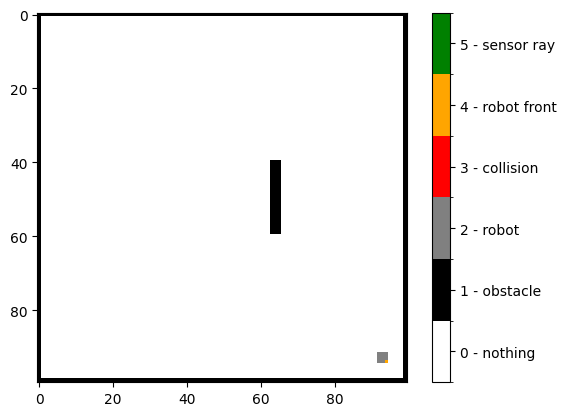

# Trajectory


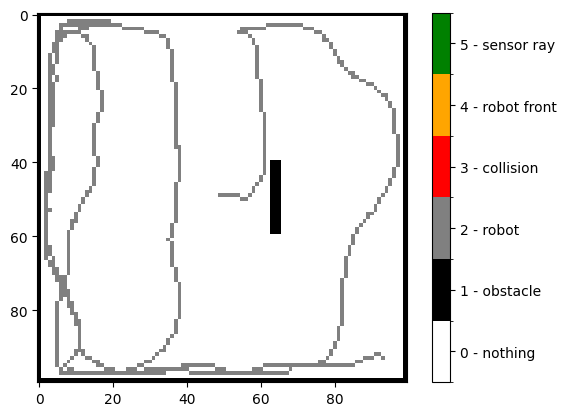

In [6]:
def my_controller_cautious_random(sensors):
    translation = 0.0
    if sensors[0] == 1.0:  # front sensor (in [0,+1], +1 means no obstacle detected)
        translation = 1.0  # max translation speed
    else:
        translation = 0.0  # no translation
    rotation = (
        random.random() - 0.5
    ) * 2.0  # rotational noise with max. amplitude (result in -1,+1)
    return translation, rotation


# Main

init()

print("#\n# Policy no.2 -- cautious-random robot\n#")

display_arena = False  # diplay step-by-step if True.
verbose_minimal_progress = (
    True  # suggested: True -- useful. Tune gap_between_... to limit the nb of messages
)
display_trace = True

# clear_arena()
create_arena_walls()
create_wall_1()

x_init = arena_size // 2 - particle_box / 2
y_init = arena_size // 2 - particle_box / 2
theta_init = 0

retValues = simulate(x_init, y_init, theta_init, my_controller_cautious_random)

print()
print("Statistiques:")
print(
    "\t translations      :", retValues["translations"]
)  # Somme des valeurs absolues de translations. valeurs normalisées entre 0 et 1.
print(
    "\t rotations         :", retValues["rotations"]
)  # Somme des valeurs absolues de rotations. Valeur normalisée entre 0 et 1.
print(
    "\t couverture        :", retValues["coverage"]
)  # taux de couverture. Valeur normalisée entre 0 et 1 (arène entièrement couverte).
print(
    "\t position initiale : (", x_init, ",", y_init, ",", theta_init, ")"
)  # init: x,y,\theta
print(
    "\t position finale   : (",
    retValues["x_pos_end"],
    ",",
    retValues["y_pos_end"],
    ",",
    retValues["theta_end"],
    ")",
)  # final: init: x,y,\theta
print()

print("# Final state")
show_arena()

print("# Trajectory")
show_trace()

**ANSWER:**

This robot performs random rotation at every iteration no matter what its sensors see. It goes straight in if there is no obstacle detected by its front sensor, otherwise it does not move forward.

# Un robot éviteur d'obstacles

#
# Policy no.3 -- obstacle-avoider robot
#
### iteration 0 / 5001 ###
### iteration 1000 / 5001 ###
### iteration 2000 / 5001 ###
### iteration 3000 / 5001 ###
### iteration 4000 / 5001 ###
### iteration 5000 / 5001 ###

Statistiques:
	 translations      : 0.9058751824016944
	 rotations         : 0.1351948411661845
	 couverture        : 0.151
	 position initiale : ( 48.5 , 48.5 , 0 )
	 position finale   : ( 56.95198267790055 , 90.32658320444779 , 5775.343271147922 )

# Final state


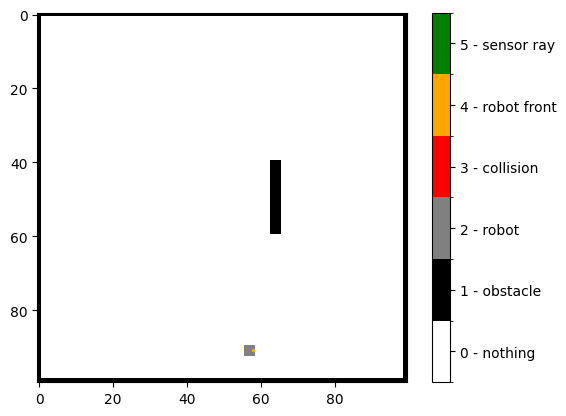

# Trajectory


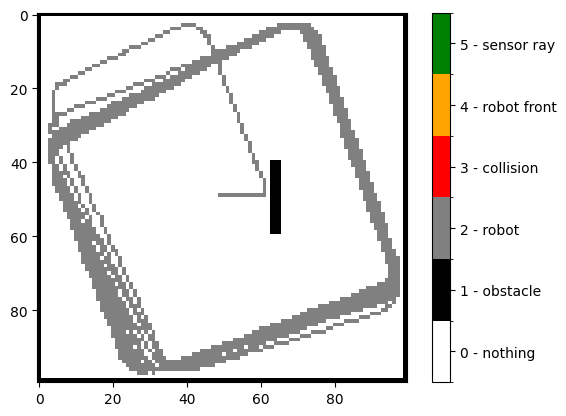

In [7]:
def my_controller_avoider(sensors):
    translation = sensors[0]
    rotation = 1.0 * sensors[1] - 1.0 * sensors[-1] + (random.random() - 0.5) * 0.1
    # print (sensors,translation,rotation,absolute_orientation)
    return translation, rotation


# Main

init()

print("#\n# Policy no.3 -- obstacle-avoider robot\n#")

display_arena = False  # diplay step-by-step if True.
verbose_minimal_progress = (
    True  # suggested: True -- useful. Tune gap_between_... to limit the nb of messages
)
display_trace = True

# clear_arena()
create_arena_walls()
create_wall_1()

x_init = arena_size // 2 - particle_box / 2
y_init = arena_size // 2 - particle_box / 2
theta_init = 0

retValues = simulate(x_init, y_init, theta_init, my_controller_avoider)

print()
print("Statistiques:")
print(
    "\t translations      :", retValues["translations"]
)  # Somme des valeurs absolues de translations. valeurs normalisées entre 0 et 1.
print(
    "\t rotations         :", retValues["rotations"]
)  # Somme des valeurs absolues de rotations. Valeur normalisée entre 0 et 1.
print(
    "\t couverture        :", retValues["coverage"]
)  # taux de couverture. Valeur normalisée entre 0 et 1 (arène entièrement couverte).
print(
    "\t position initiale : (", x_init, ",", y_init, ",", theta_init, ")"
)  # init: x,y,\theta
print(
    "\t position finale   : (",
    retValues["x_pos_end"],
    ",",
    retValues["y_pos_end"],
    ",",
    retValues["theta_end"],
    ")",
)  # final: init: x,y,\theta
print()

print("# Final state")
show_arena()

print("# Trajectory")
show_trace()

**ANSWER:**

The robot slows down when the front sensor detects a wall. It goes in the direction of the higher value sensor between the front-left and front-right sensor.

# Affichage pas à pas de la simulation

Utile pour étudier la trajectoire d'un robot, mais très lent. A utiliser avec extrême parcimonie.

Exemple avec le "robot prudent mais fébrile".

### iteration 0 / 5001 ###
### iteration 1000 / 5001 ###
### iteration 2000 / 5001 ###
### iteration 3000 / 5001 ###
### iteration 4000 / 5001 ###
### iteration 5000 / 5001 ###


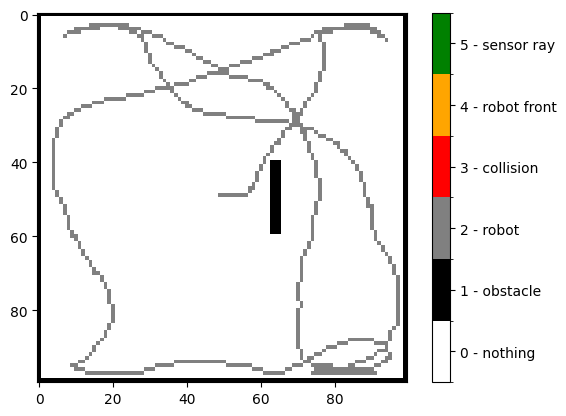

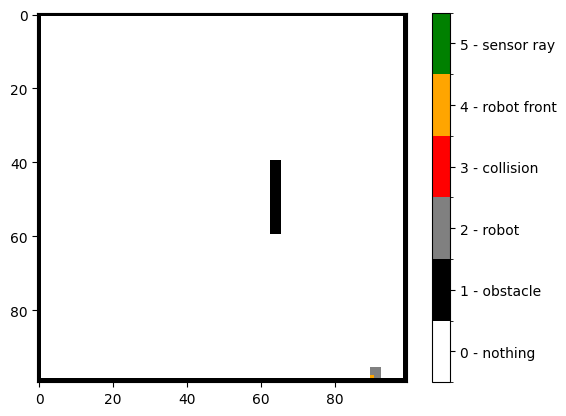


Statistiques:
	 translations      : 0.13717256548690263
	 rotations         : 0.4976101433054783
	 couverture        : 0.0632
	 position initiale : ( 48.5 , 48.5 , 0 )
	 position finale   : ( 90.6377318719021 , 96.22916249420769 , 241.87780024884026 )



In [8]:
# initial conditions

x_init = arena_size // 2 - particle_box / 2
y_init = arena_size // 2 - particle_box / 2
theta_init = 0

display_trace = True
display_arena = False  # True

init()  # perform only once
create_arena_walls()
create_wall_1()

retValues = simulate(x_init, y_init, theta_init, my_controller_cautious_random)
show_trace()
show_arena()

print()
print("Statistiques:")
print(
    "\t translations      :", retValues["translations"]
)  # Somme des valeurs absolues de translations. valeurs normalisées entre 0 et 1.
print(
    "\t rotations         :", retValues["rotations"]
)  # Somme des valeurs absolues de rotations. Valeur normalisée entre 0 et 1.
print(
    "\t couverture        :", retValues["coverage"]
)  # taux de couverture. Valeur normalisée entre 0 et 1 (arène entièrement couverte).
print(
    "\t position initiale : (", x_init, ",", y_init, ",", theta_init, ")"
)  # init: x,y,\theta
print(
    "\t position finale   : (",
    retValues["x_pos_end"],
    ",",
    retValues["y_pos_end"],
    ",",
    retValues["theta_end"],
    ")",
)  # final: init: x,y,\theta
print()

---
---
---

# <font color="orange">Partie 2. Prise en main : exploration de l'espace des politiques</font>

Nous allons utiliser le code précédent pour générer au hasard des politiques, en variant les paramètres d'une fonction simple de contrôle. La politique du robot est dirigée par une combinaison linéaire de quatre entrées sensorielles. Les poids appliqués sur les entrées sont tirés au hasard entre chaque essai. La variable globale *weights* est utilisée pour stocker les paramètres de la politique.

<font color="red">EXERCICE :</font>

- Exécutez et étudiez l'exemple de recherche au hasard. Observez en particulier comme la politique est modifiée entre chaque essai. Observez aussi la direction préférentielle du robot (vers l'avant ou vers l'arrière?).

- modifiez le code de la recherche au hasard pour calculer la fitness de "*déplacement*" vu en cours (maximiser la vitesse de translation, minimiser la vitesse de rotation -- on oublie les senseurs!) en utilisant les données  retournées par une simulation. Vous devrez (1) écrire la fonction fitness qui lance une simulation et renvoie la performance et (2) conserver le meilleur individu. Vous ferez 200 essais.

- rejouez le meilleur individu en affichant uniquement la trajectoire complète, la position finale, la performance donnée par la fitness et les données produites par la simulation (translations, rotations, couverture, position x/y à la fin).

#
# random exploration of the policy space using a linear weighted combination of sensory inputs#
run no. 1 of 20
### iteration 0 / 501 ###
{'translations': 0.9999999999999999, 'rotations': 1.0, 'coverage': np.float64(0.0034), 'x_pos_end': 45.575499626201825, 'y_pos_end': 49.01566832099251, 'theta_end': -5010.0}


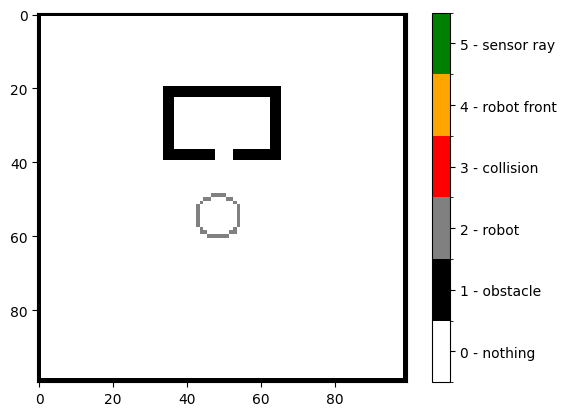

run no. 2 of 20
### iteration 0 / 501 ###
{'translations': 0.803231587784249, 'rotations': 0.36511320135512615, 'coverage': np.float64(0.0369), 'x_pos_end': 11.08853732215112, 'y_pos_end': 88.66643512143034, 'theta_end': -1829.217138789173}


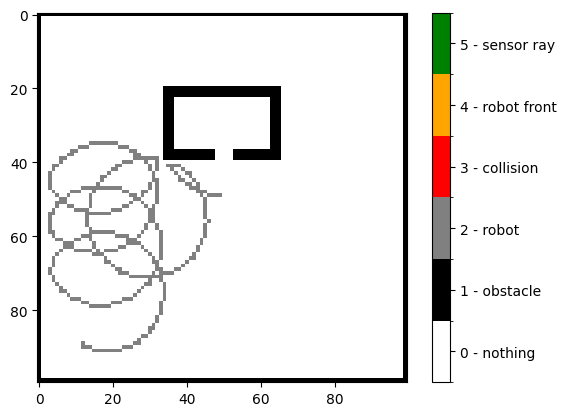

run no. 3 of 20
### iteration 0 / 501 ###
{'translations': 0.9999999999999999, 'rotations': 1.0, 'coverage': np.float64(0.0034), 'x_pos_end': 45.575499626201825, 'y_pos_end': 49.01566832099251, 'theta_end': -5010.0}


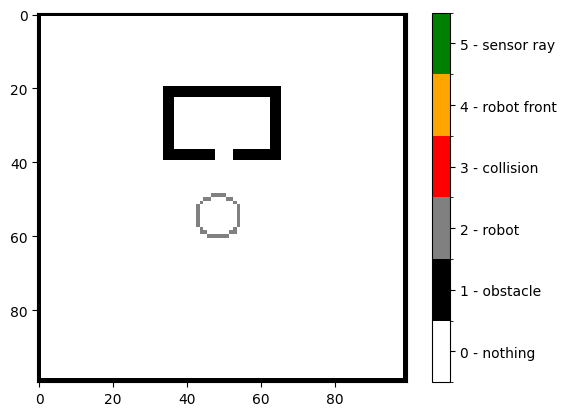

run no. 4 of 20
### iteration 0 / 501 ###
{'translations': 0.04381941033069116, 'rotations': 0.059970846827702325, 'coverage': np.float64(0.001), 'x_pos_end': 43.878598394565614, 'y_pos_end': 44.581250465714284, 'theta_end': -120.1506607067333}


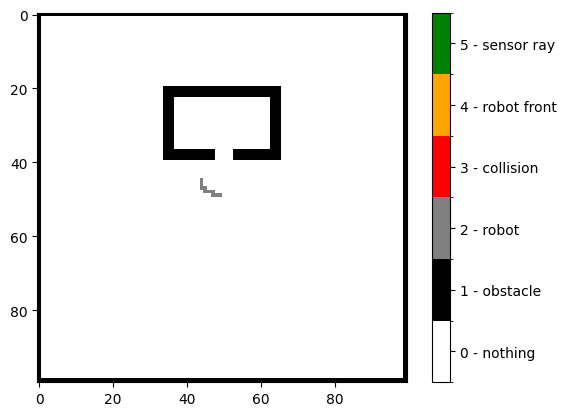

run no. 5 of 20
### iteration 0 / 501 ###
{'translations': 0.5481581614195299, 'rotations': 0.5181795400295252, 'coverage': np.float64(0.0245), 'x_pos_end': 78.94714386564463, 'y_pos_end': 27.8707125914497, 'theta_end': 2596.0794955479155}


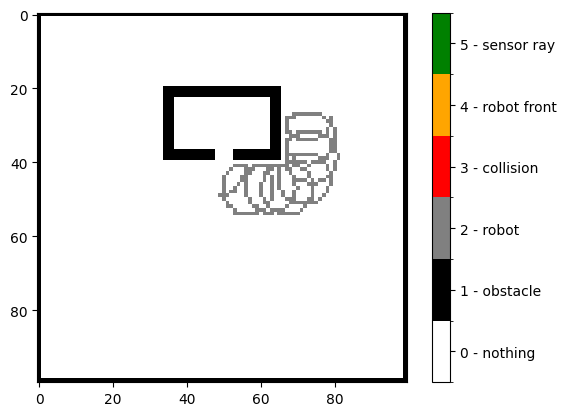

run no. 6 of 20
### iteration 0 / 501 ###
{'translations': 0.9999999999999999, 'rotations': 1.0, 'coverage': np.float64(0.0034), 'x_pos_end': 51.424500373798175, 'y_pos_end': 49.01566832099251, 'theta_end': 5010.0}


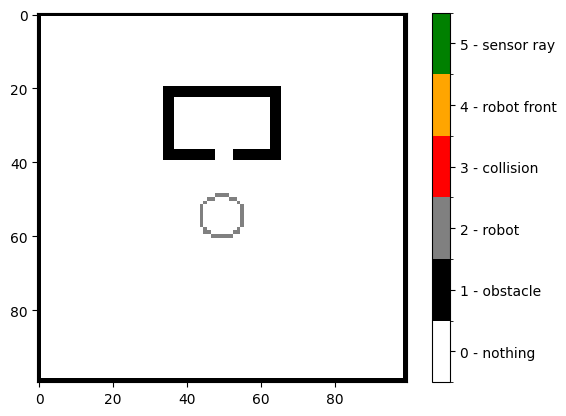

run no. 7 of 20
### iteration 0 / 501 ###
{'translations': 0.8239442929830025, 'rotations': 0.32811656933709293, 'coverage': np.float64(0.0334), 'x_pos_end': 66.61313645801485, 'y_pos_end': 38.64383135932277, 'theta_end': -1386.7894109334813}


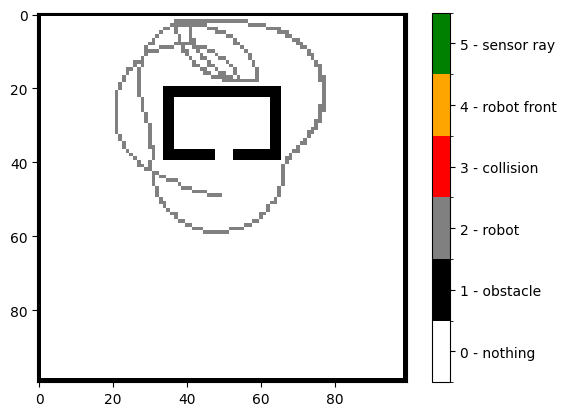

run no. 8 of 20
### iteration 0 / 501 ###
{'translations': 0.07715772585307734, 'rotations': 0.14652512984393112, 'coverage': np.float64(0.0024), 'x_pos_end': 49.2333456623412, 'y_pos_end': 48.60016999650694, 'theta_end': -734.0909005180864}


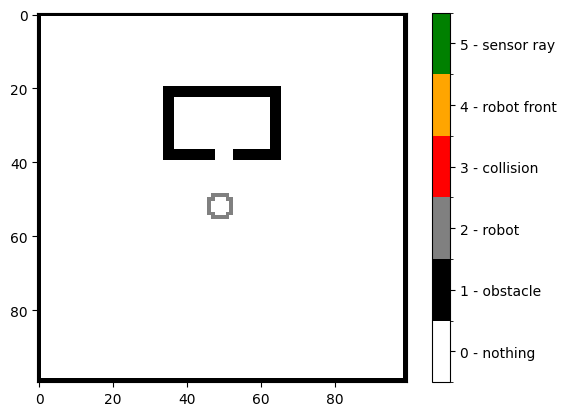

run no. 9 of 20
### iteration 0 / 501 ###
{'translations': 0.041916167664670656, 'rotations': 0.31517155281595977, 'coverage': np.float64(0.0021), 'x_pos_end': 64.7641626498975, 'y_pos_end': 40.01784889000094, 'theta_end': 46.276017441612034}


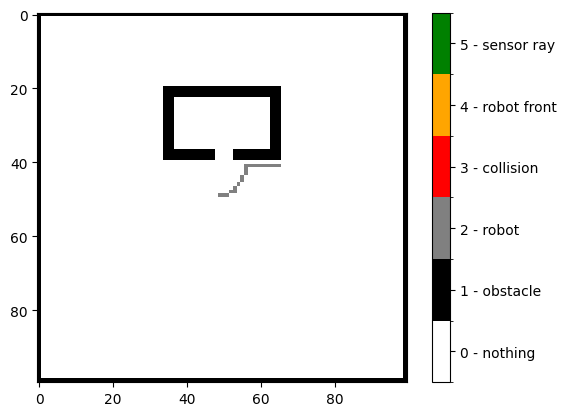

run no. 10 of 20
### iteration 0 / 501 ###
{'translations': 0.37269608809693716, 'rotations': 1.0, 'coverage': np.float64(0.0014), 'x_pos_end': 49.58994984895263, 'y_pos_end': 48.69218756598951, 'theta_end': 5010.0}


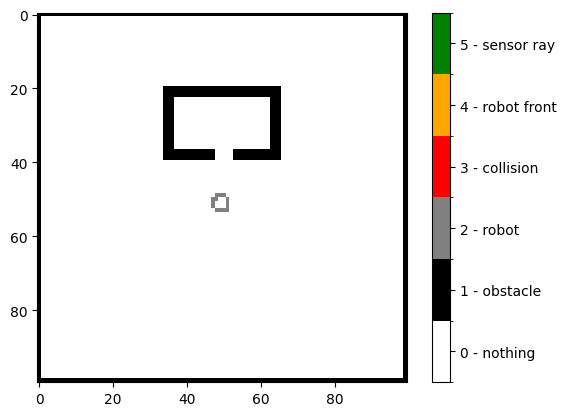

run no. 11 of 20
### iteration 0 / 501 ###
{'translations': 0.1796599970918299, 'rotations': 1.0, 'coverage': np.float64(0.0008), 'x_pos_end': 47.82319620252484, 'y_pos_end': 48.5927998851757, 'theta_end': -5010.0}


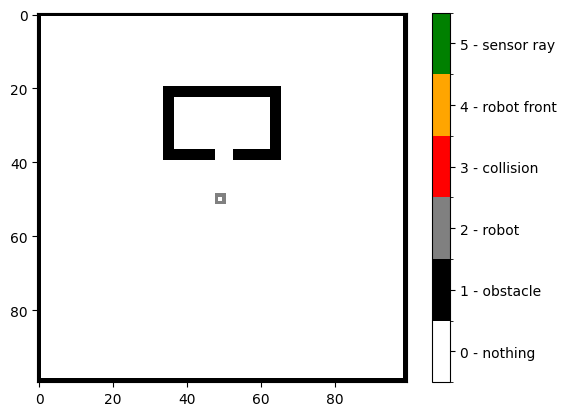

run no. 12 of 20
### iteration 0 / 501 ###
{'translations': 0.07678187326475114, 'rotations': 1.0, 'coverage': np.float64(0.0002), 'x_pos_end': 48.27545138293632, 'y_pos_end': 48.5395939796691, 'theta_end': -5010.0}


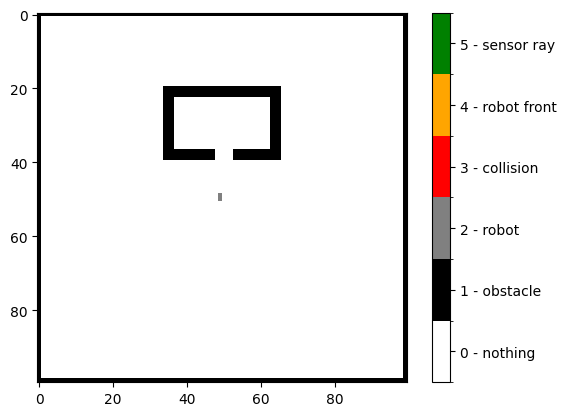

run no. 13 of 20
### iteration 0 / 501 ###
{'translations': 0.874251497005988, 'rotations': 0.8930784231949896, 'coverage': np.float64(0.0182), 'x_pos_end': 60.00719859805078, 'y_pos_end': 40.124521195173685, 'theta_end': 4474.322900206898}


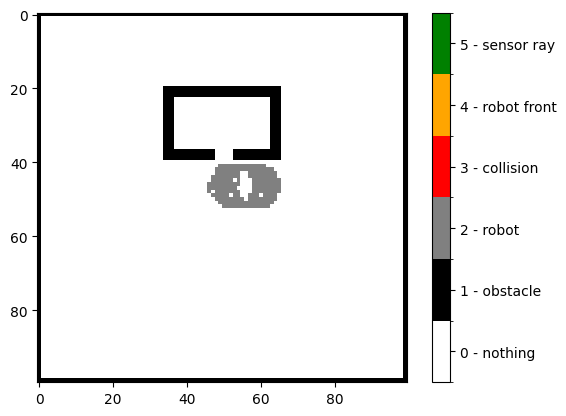

run no. 14 of 20
### iteration 0 / 501 ###
{'translations': 0.24535298443638606, 'rotations': 0.5658938269583575, 'coverage': np.float64(0.0024), 'x_pos_end': 45.872645661561826, 'y_pos_end': 49.13555858261851, 'theta_end': -2835.12807306133}


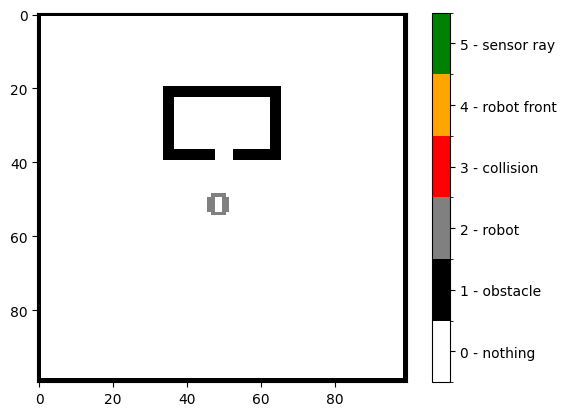

run no. 15 of 20
### iteration 0 / 501 ###
{'translations': 0.13700402724141247, 'rotations': 0.7971568091103345, 'coverage': np.float64(0.0008), 'x_pos_end': 47.96527066869186, 'y_pos_end': 48.70380402225866, 'theta_end': 3993.75561364283}


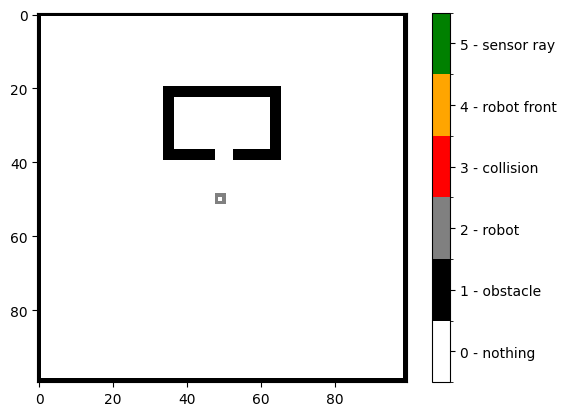

run no. 16 of 20
### iteration 0 / 501 ###
{'translations': 0.02547603944790419, 'rotations': 1.0, 'coverage': np.float64(0.0001), 'x_pos_end': 48.57450468688829, 'y_pos_end': 48.51313718648764, 'theta_end': 5010.0}


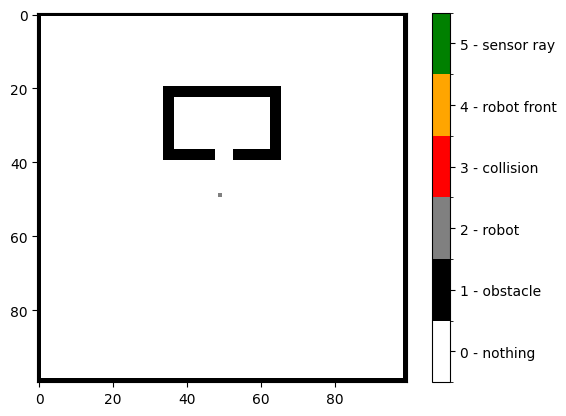

run no. 17 of 20
### iteration 0 / 501 ###
{'translations': 0.6525963973383389, 'rotations': 0.8831670137051899, 'coverage': np.float64(0.0034), 'x_pos_end': 44.82124266773839, 'y_pos_end': 54.11086750191962, 'theta_end': 4424.666738662975}


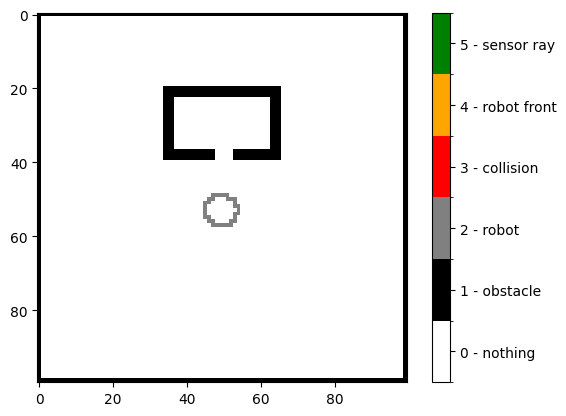

run no. 18 of 20
### iteration 0 / 501 ###
{'translations': 0.8186116042024951, 'rotations': 0.4627773153997503, 'coverage': np.float64(0.0341), 'x_pos_end': 17.165563396865007, 'y_pos_end': 36.01877260169433, 'theta_end': -2310.9834485290567}


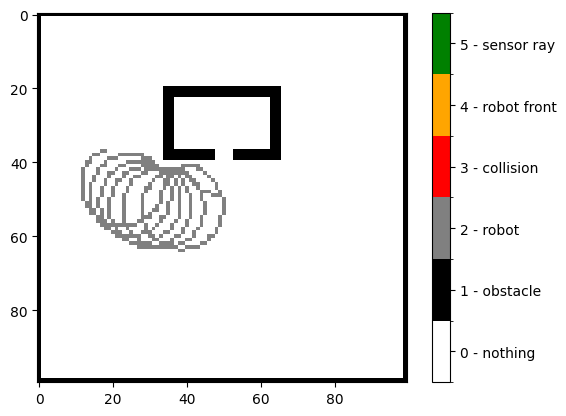

run no. 19 of 20
### iteration 0 / 501 ###
{'translations': 0.4557051885491169, 'rotations': 0.1294925462972587, 'coverage': np.float64(0.0241), 'x_pos_end': 36.1670385719179, 'y_pos_end': 62.42461907057976, 'theta_end': -648.7576569492668}


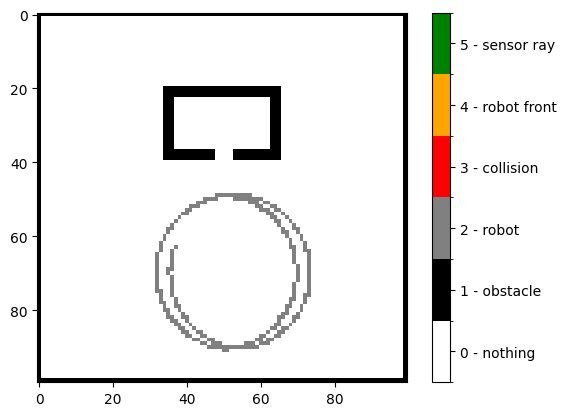

run no. 20 of 20
### iteration 0 / 501 ###
{'translations': 0.5959143666239957, 'rotations': 0.5932397761436543, 'coverage': np.float64(0.0046), 'x_pos_end': 53.60292279953164, 'y_pos_end': 54.77382773336868, 'theta_end': -2972.1312784796764}


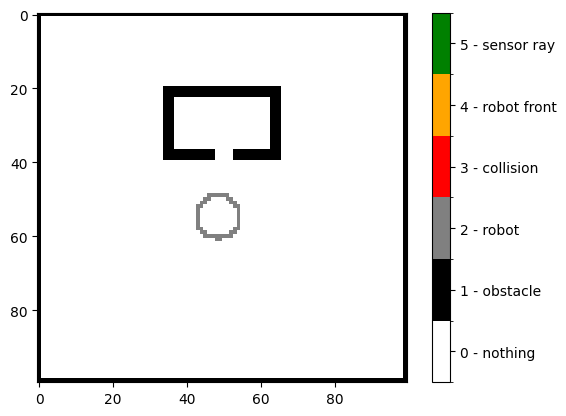

Terminé.


In [9]:
def my_controller_NN_4sensors(sensors):
    global weights
    translation = (
        weights[0] * sensors[-2]
        + weights[1] * sensors[0]
        + weights[2] * sensors[2]
        + weights[3] * sensors[4]
        + weights[4]
    )
    rotation = (
        weights[5] * sensors[-2]
        + weights[6] * sensors[0]
        + weights[7] * sensors[2]
        + weights[8] * sensors[4]
        + weights[9]
    )
    # print (sensors,translation,rotation,absolute_orientation)
    return translation, rotation


print(
    "#\n# random exploration of the policy space using a linear weighted combination of sensory inputs#"
)

display_arena = False  # diplay step-by-step if True.
display_trace = True

init()

# clear_arena()
create_arena_walls()
create_wall_2(-20)

x_init = arena_size // 2 - particle_box / 2
y_init = arena_size // 2 - particle_box / 2
theta_init = 0

nb_runs = 20
max_iterations = 501

for i in range(nb_runs):
    print("run no.", (i + 1), "of", nb_runs)
    weights = np.random.uniform(-1.0, 1.0, size=10).tolist()
    retValues = simulate(x_init, y_init, 0, my_controller_NN_4sensors)
    print(retValues)
    show_trace()

print("Terminé.")

**ANSWER:**

In many cases the robot goes in circles as the effect of the sensors is never discovered (in its path it never encounters walls). This results in constant translations and rotations which corresponds to a circular path.

In other cases the effect of the sensors on the movement of the robot can be seen causing a deviation of the trajectories. The preferred direction of the robots is when the sensors don't detect anything which is $\sum_{i=0}^{4} \texttt{weights[i]}$ which is forward when this is positive and backwards when this is negative. The preferred rotation is the same for $\sum_{i=5}^{9} \texttt{weights[i]}$ which corresponds to left when positive and right when negative.

0.7958114794187012
[0.27655375773066315, -0.4126539880079325, 0.6759672826077505, 0.8487697483083465, 0.6119477977917016, -0.21770052501110038, 0.6911668169004661, 0.6157209881693109, -0.27260411449099564, -0.8301633269538922]
{'translations': 0.93812375249501, 'rotations': 0.15169882725793774, 'coverage': np.float64(0.0444), 'x_pos_end': 19.080688442905085, 'y_pos_end': 61.32010574153093, 'theta_end': -671.1393666843686}


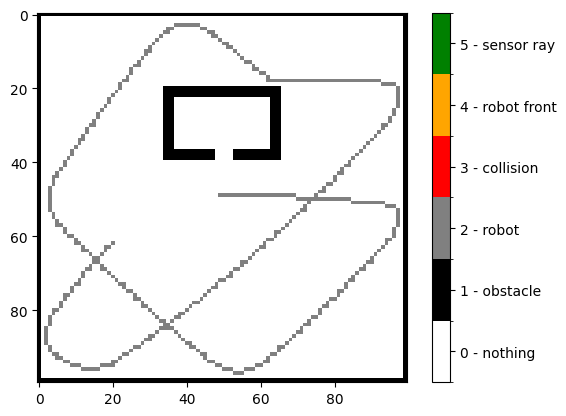

In [10]:
def fitness(x0=x_init, y0=y_init, orientation0=0, step=my_controller_NN_4sensors):
    retValues = simulate(x0, y0, orientation0, step)
    fitness = retValues["translations"] * (1 - retValues["rotations"])
    return fitness


verbose_minimal_progress = False
weights = np.random.uniform(-1.0, 1.0, size=10).tolist()
best_weights = weights.copy()
best_fitness = fitness()
for _ in range(199):
    weights = np.random.uniform(-1.0, 1.0, size=10).tolist()
    fit = fitness()
    if fit >= best_fitness:
        best_fitness = fit
        best_weights = weights.copy()

print(best_fitness)
print(best_weights)

# --- Show the best found

weights = best_weights.copy()

display_arena = False  # diplay step-by-step if True.
display_trace = True

init()

# clear_arena()
create_arena_walls()
create_wall_2(-20)

x_init = arena_size // 2 - particle_box / 2
y_init = arena_size // 2 - particle_box / 2
theta_init = 0

retValues = simulate(x_init, y_init, 0, my_controller_NN_4sensors)
print(retValues)
show_trace()

We seem to find that the best agent does not draw circles and prefers long straight-ish trajectories (usually)

---
---
---

# <font color="orange">Partie 3. Evolution</font>

A partir du code précédent, nous allons maintenant implémenter deux algorithmes d'évolution artificielle vue lors de la séance précédente: (1+1)-ES et CMAES (n'hésitez pas à faire des copier-coller). Pour ne pas alourdir l'affichage, vous pouvez vous contenter d'afficher uniquement la valeur de la fitness pour chaque individu évalué pendant l'évolution.

<font color="red">EXERCICES :</font>

- en utilisant le code que vous avez réalisé lors du dernier TP, implémentez l'algorithme (1+1)-ES (avec la règle des 1/5e si vous l'avez fait) pour optimiser la fitness de déplacement précédemment implémentée. Lancez l'algorithme sur 200 itérations, affichez le meilleur résultat (performance et graphes).

- Idem avec CMAES. Pour limiter le budget d'évaluations de CMAES vous pouvez utiliser la commande *es.opts.set({'maxfevals': mon_budget_en_evaluations})*. A noter que CMAES s'arrétera *à la fin* de la première génération qui aura épuisée le budget d'évaluations, ie. le nombre d'évaluations effective peut dépasser la limite prévue par le budget -- on considère que c'est négligeable ici.

- Comparez (1+1)-ES et CMAES en générant les courbes montrant l'évolution des best-evers au cours du temps pour chaque algorithmes.

# (1+1)-ES 1/5th rule


#
# (1+1)-ES 1/5th rule for maximising translation and minimasing rotation#
it = 0 , current_fit = 0.0 , best_fit = 0.0
it = 20 , current_fit = 0.1039396684998276 , best_fit = 0.8171789742097127
it = 40 , current_fit = 0.7924406386134103 , best_fit = 0.8232544702289578
it = 60 , current_fit = 0.7864435168328228 , best_fit = 0.8351081110178517
it = 80 , current_fit = 0.8349173964678005 , best_fit = 0.837597722185608
it = 100 , current_fit = 0.8411347911268874 , best_fit = 0.8445383333306098
it = 120 , current_fit = 0.8336652448381117 , best_fit = 0.8445396797769986
it = 140 , current_fit = 0.8445038236570648 , best_fit = 0.8445418456065453
it = 160 , current_fit = 0.844270857779103 , best_fit = 0.8445418909506898
it = 180 , current_fit = 0.8442703532774839 , best_fit = 0.8445419254196177
it = 200 , current_fit = 0.8445419347077401 , best_fit = 0.8445419347077401
Best fit 0.8445419347077401 found at iteration 200

Rejoue et affiche la meilleure solution
[1.3097221842812345, 1.12201501475

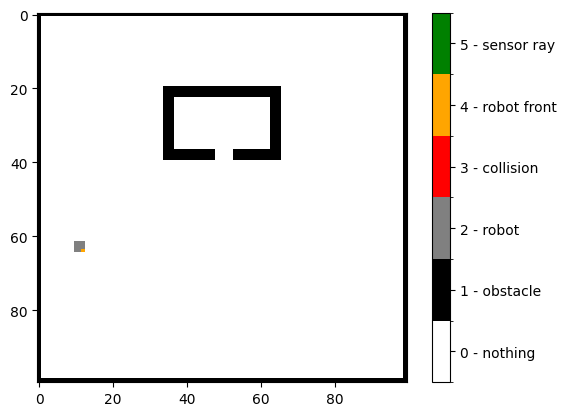

# Trajectory


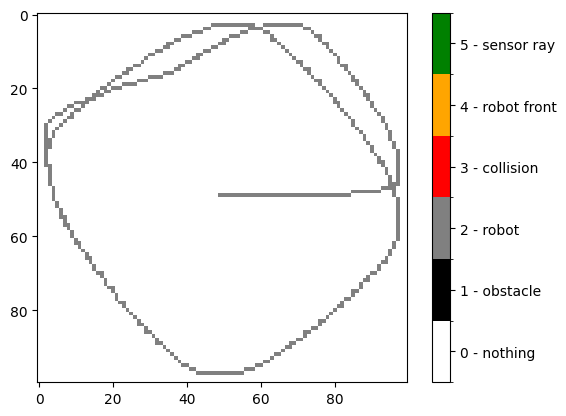

Terminé.


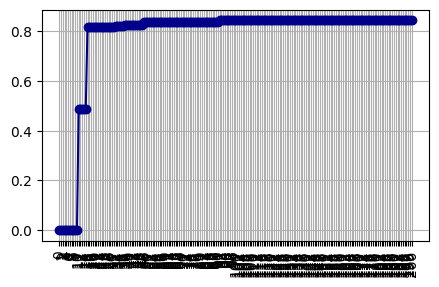

In [11]:
def launch_oneplusone_withOneFifthRule(
    individual, sigma_init, nbeval, display, ma_func
):
    # !!!!!! !!!!!! !!!!!! !!!!!! !!!!!! A COMPLETER !!!!!! !!!!!! !!!!!! !!!!!! !!!!!!
    sigma = sigma_init
    i = 0
    besteverFit = -float("inf")
    besteverIt = 0
    besteverSolution = individual
    data = []
    while i < nbeval:
        candidateSolution = np.random.randn(len(individual)) * sigma + besteverSolution
        fit = ma_func(candidateSolution)
        if fit >= besteverFit:
            besteverSolution = np.copy(candidateSolution)
            besteverFit = fit
            besteverIt = i
            sigma *= 2
        else:
            sigma *= 2 ** (-1 / 4)
        data.append(besteverFit)
        if display and i % (int(nbeval / 10)) == 0:
            print("it =", i, ", current_fit =", fit, ", best_fit =", besteverFit)
        i += 1
    print("Best fit", besteverFit, "found at iteration", besteverIt)
    # !!!!!! !!!!!! !!!!!! !!!!!! !!!!!! A COMPLETER !!!!!! !!!!!! !!!!!! !!!!!! !!!!!!
    return besteverIt, besteverFit, besteverSolution, data


def my_fitness_func_maximize(params):  # fitness function
    global x_init, y_init, theta_init, weights
    weights = params
    retValues = simulate(x_init, y_init, theta_init, my_controller_NN_4sensors)
    # !!!!!! !!!!!! !!!!!! !!!!!! !!!!!! A COMPLETER !!!!!! !!!!!! !!!!!! !!!!!! !!!!!!
    # !!!!!! !!!!!! !!!!!! !!!!!! !!!!!! A COMPLETER !!!!!! !!!!!! !!!!!! !!!!!! !!!!!!
    fitness = retValues["translations"] * (1 - retValues["rotations"])
    # !!!!!! !!!!!! !!!!!! !!!!!! !!!!!! A COMPLETER !!!!!! !!!!!! !!!!!! !!!!!! !!!!!!
    # !!!!!! !!!!!! !!!!!! !!!!!! !!!!!! A COMPLETER !!!!!! !!!!!! !!!!!! !!!!!! !!!!!!
    if display_trace == True:  # noqa: E712
        show_trace()
    return fitness


# Main

print("#\n# (1+1)-ES 1/5th rule for maximising translation and minimasing rotation#")

display_arena = False  # diplay step-by-step if True.
verbose_minimal_progress = (
    False  # suggested: True -- useful. Tune gap_between_... to limit the nb of messages
)
display_trace = False

init()

# clear_arena()
create_arena_walls()
create_wall_2(-20)

max_iterations = 501  # nb of simulation iterations for one robot
max_iterations_evolve = 201  # nb of evolution iterations

x_init = arena_size // 2 - particle_box / 2
y_init = arena_size // 2 - particle_box / 2
theta_init = 0

initial_solution = np.random.uniform(-1.0, 1.0, size=10).tolist()
besteverIt, besteverFit, besteverSolution, data = launch_oneplusone_withOneFifthRule(
    initial_solution,
    nbeval=max_iterations_evolve,
    sigma_init=0.0001,
    display=True,
    ma_func=my_fitness_func_maximize,
)

print("\nRejoue et affiche la meilleure solution")

weights = np.copy(besteverSolution).tolist()
print(weights)
retValues = simulate(x_init, y_init, theta_init, my_controller_NN_4sensors)

print(retValues)
print("# Final state")
show_arena()
print("# Trajectory")
show_trace()
print("Terminé.")


def plot_data(
    data, title=None, x_label=None, y_label=None, interval=1, y_min=None, y_max=None
):
    x_values = range(0, len(data), interval)
    y_values = data[::interval]
    x_ticks = range(len(data))[::interval]
    plt.figure(figsize=(5, 3))
    plt.plot(x_values, y_values, marker="o", linestyle="-", color="darkblue")
    if title is not None:
        plt.title(title)
    if x_label is not None:
        plt.xlabel(x_label)
    if y_label is not None:
        plt.ylabel(y_label)
    plt.grid(True)
    plt.xticks(x_ticks)
    plt.xticks(rotation=90)
    if y_min is not None and y_max is not None:
        plt.ylim(y_min, y_max)
    plt.show()


plot_data(data)


# CMAES




=-=-=-=-=
=-=-=-=-= Robot with CMA-ES
=-=-=-=-=
(5_w,10)-aCMA-ES (mu_w=3.2,w_1=45%) in dimension 10 (seed=1000747, Thu Mar 19 17:48:19 2026)
0 : -0.000568257522561738
1 : -0.0710364253836461
2 : -0.21894627075661585
3 : -0.42450433979822316
4 : -0.0
5 : -0.02721726190984748
6 : -0.0
7 : -0.023573358812009844
8 : -0.09154676747237413
9 : -0.0
Iterat #Fevals   function value  axis ratio  sigma  min&max std  t[m:s]
    1     10 -4.245043397982232e-01 1.0e+00 9.38e-01  9e-01  9e-01 0:00.7
10 : -0.0346770864572046
11 : -0.0013873967399077394
12 : -0.0
13 : -0.6722315281820012
14 : -0.5488144145139211
15 : -0.08109434555991146
16 : -0.36283180618330924
17 : -0.013897981738129648
18 : -0.0
19 : -0.034058848853386704
    2     20 -6.722315281820012e-01 1.1e+00 9.51e-01  9e-01  1e+00 0:01.4
20 : -0.0020720259160426197
21 : -0.004995015379981055
22 : -0.07332489194456666
23 : -0.09519629151223419
24 : -0.663323668135841
25 : -0.0
26 : -5.645146851987239e-05
27 : -0.0
28 : -0.05892292399355022
2

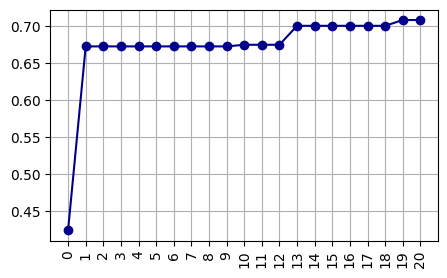

besteverFitness -0.7078075829665352
besteverParams [ 0.32773133 -0.8296755  -0.1915354   0.93527868 -1.77168802  0.30952843
  0.35350575 -0.14949809  0.73527162 -1.0567467 ]
210 : -0.7078075829665352
-0.7078075829665352
# Final state


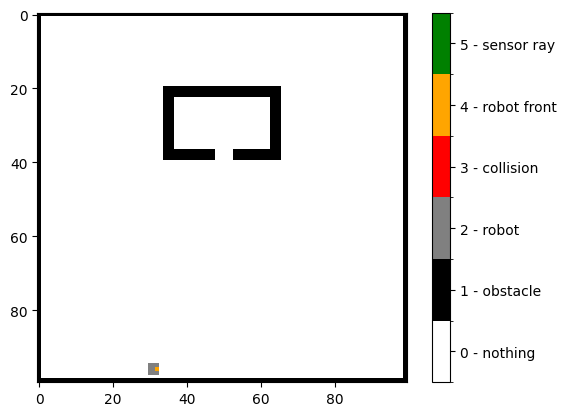

# Trajectory


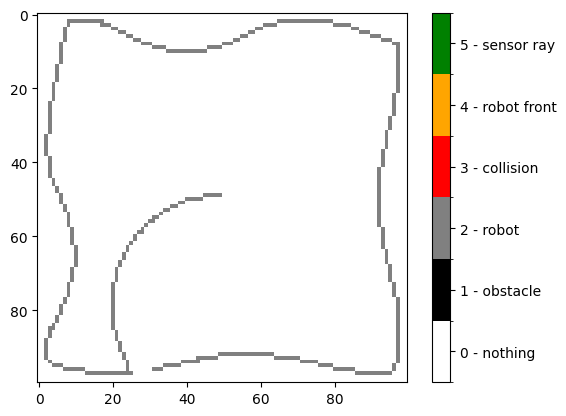

Terminé.


In [12]:
def launch_cmaes(dim, display, ma_func, max_evaluations):
    # !!!!!! !!!!!! !!!!!! !!!!!! !!!!!! A COMPLETER !!!!!! !!!!!! !!!!!! !!!!!! !!!!!!
    es = cma.CMAEvolutionStrategy(
        x0=np.random.uniform(-1, 1, dim),
        sigma0=1,
        inopts={"maxfevals": max_evaluations},
    )

    data = []
    while not es.stop():
        solutions = es.ask()
        es.tell(solutions, [ma_func(s) for s in solutions])
        es.disp()
        data.append(-es.result.fbest)

    if display:
        plot_data(data)
    # !!!!!! !!!!!! !!!!!! !!!!!! !!!!!! A COMPLETER !!!!!! !!!!!! !!!!!! !!!!!! !!!!!!
    return es.result.fbest, es.result.xbest


def my_fitness_func_for_cmaes(params):
    global x_init, y_init, theta_init, weights, eval
    weights = params
    retValues = simulate(x_init, y_init, theta_init, my_controller_NN_4sensors)
    # !!!!!! !!!!!! !!!!!! !!!!!! !!!!!! A COMPLETER !!!!!! !!!!!! !!!!!! !!!!!! !!!!!!
    # !!!!!! !!!!!! !!!!!! !!!!!! !!!!!! A COMPLETER !!!!!! !!!!!! !!!!!! !!!!!! !!!!!!
    fitness = -retValues["translations"] * (1 - retValues["rotations"])
    # !!!!!! !!!!!! !!!!!! !!!!!! !!!!!! A COMPLETER !!!!!! !!!!!! !!!!!! !!!!!! !!!!!!
    # !!!!!! !!!!!! !!!!!! !!!!!! !!!!!! A COMPLETER !!!!!! !!!!!! !!!!!! !!!!!! !!!!!!
    if display_trace == True:
        show_trace()
    print(eval, ":", fitness)
    eval += 1
    return fitness


# display debug options

display_arena = False  # step-by-step display.
verbose_minimal_progress = (
    False  # suggested: True -- useful. Tune gap_between_... to limit the nb of messages
)
display_trace = False

# experimental settings

arena_size = 100
max_translation_per_step = 1.0  # >0. pixel per move.
max_rotation_per_step = 10.0  # >0, in degrees
max_iterations = 501  # nb of simulator iterations for evaluating one robot
max_iterations_evolve = 201  # nb of evolution iterations

# initial conditions

x_init = arena_size // 2 - particle_box / 2
y_init = arena_size // 2 - particle_box / 2
theta_init = 0

init()  # perform only once
create_arena_walls()
create_wall_2(-20)

print("\n=-=-=-=-=\n=-=-=-=-= Robot with CMA-ES\n=-=-=-=-=")

eval = 0
besteverFitness, besteverParams = launch_cmaes(
    dim=10,
    display=True,  # Note
    ma_func=my_fitness_func_for_cmaes,
    max_evaluations=max_iterations_evolve,
)

print("besteverFitness", besteverFitness)
print("besteverParams", besteverParams)

retValues = my_fitness_func_for_cmaes(besteverParams)

print(retValues)
print("# Final state")
show_arena()
print("# Trajectory")
show_trace()
print("Terminé.")


The curve for (1+1)-ES shows quite fast learning with convergence in about ~100 steps with fitness value ~0.77. For CMAES it is quite similar.

# Replay

A toutes fins utiles, exécutez cette cellule pour obtenir un replay (avec affichage pas à pas si display_arena=True) de la trajectoire du robot avec les meilleurs paramètres. Veillez à ce que *besteverParams* contienne bien les paramètres voulus (ce qui est le cas si vous venez d'exécutez la cellule précédente).

besteverFitness -0.7078075829665352
besteverParams [ 0.32773133 -0.8296755  -0.1915354   0.93527868 -1.77168802  0.30952843
  0.35350575 -0.14949809  0.73527162 -1.0567467 ]


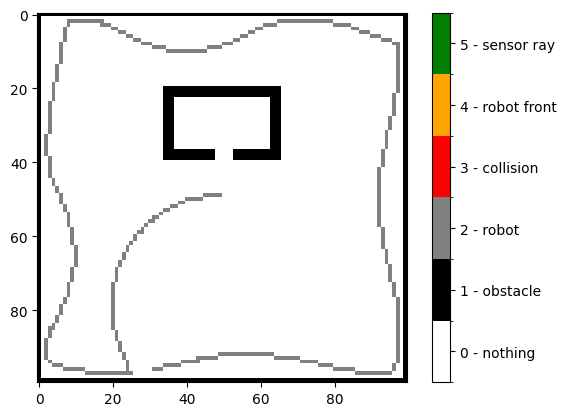

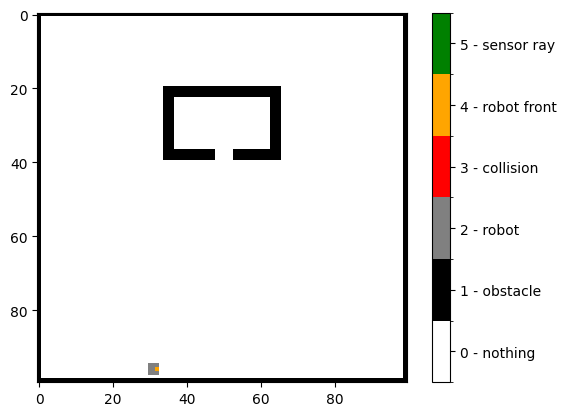


Statistiques:
	 translations      : 0.8622754491017964
	 rotations         : 0.17913981697630982
	 couverture        : 0.0422
	 position initiale : ( 48.5 , 48.5 , 0 )
	 position finale   : ( 30.250180386892097 , 95.43867861900922 , -348.95206986883255 )



In [13]:
# initial conditions

x_init = arena_size // 2 - particle_box / 2
y_init = arena_size // 2 - particle_box / 2
theta_init = 0

display_trace = True
display_arena = False

init()  # perform only once
create_arena_walls()
create_wall_2(-20)

print("besteverFitness", besteverFitness)
print("besteverParams", besteverParams)

weights = besteverParams
retValues = simulate(x_init, y_init, theta_init, my_controller_NN_4sensors)
show_trace()
show_arena()

print()
print("Statistiques:")
print(
    "\t translations      :", retValues["translations"]
)  # Somme des valeurs absolues de translations. valeurs normalisées entre 0 et 1.
print(
    "\t rotations         :", retValues["rotations"]
)  # Somme des valeurs absolues de rotations. Valeur normalisée entre 0 et 1.
print(
    "\t couverture        :", retValues["coverage"]
)  # taux de couverture. Valeur normalisée entre 0 et 1 (arène entièrement couverte).
print(
    "\t position initiale : (", x_init, ",", y_init, ",", theta_init, ")"
)  # init: x,y,\theta
print(
    "\t position finale   : (",
    retValues["x_pos_end"],
    ",",
    retValues["y_pos_end"],
    ",",
    retValues["theta_end"],
    ")",
)  # final: init: x,y,\theta
print()

---
---
---

# <font color="orange">Partie 4. Robustesse et généralisation</font>

Nous avons jusqu'ici utilisé les mêmes valeurs pour la position et l'orientation initiale. Cependant cela peut provoquer un surapprentissage dépendant de ces conditions initiales. C'est ce que nous allons étudier ici.

<font color="red">EXERCICES :</font>

- Testez le résultat obtenu précédemment par CMAES (ie. sans relancer l'optimisation) en utilisant *create_wall_2()* à la place de *create_wall_2(-20)* pour construire l'environnement. Exécutez et commentez le résultat.

- Relancez l'optimisation avec CMAES en utilisant *create_wall_2()* comme condition initiale. Commentez le résultat.

- Modifier l'évaluation d'un individu pour choisir aléatoire le point de départ du robot: soit au centre de l'arène, soit au centre de la mini-arène définie par *create_wall_2(-20)*. Qu'observez-vous? Commentez. en particulier: comment faire mieux dans le cas général?



besteverFitness -0.7078075829665352
besteverParams [ 0.32773133 -0.8296755  -0.1915354   0.93527868 -1.77168802  0.30952843
  0.35350575 -0.14949809  0.73527162 -1.0567467 ]


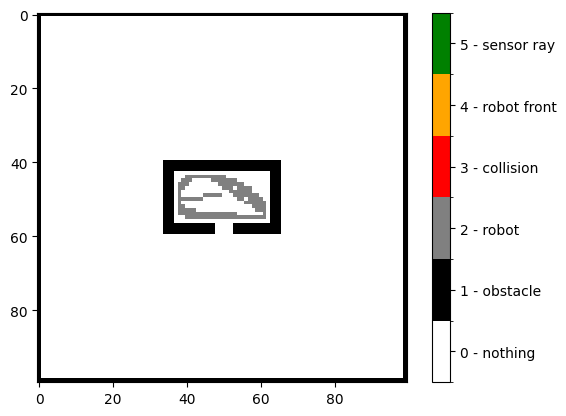

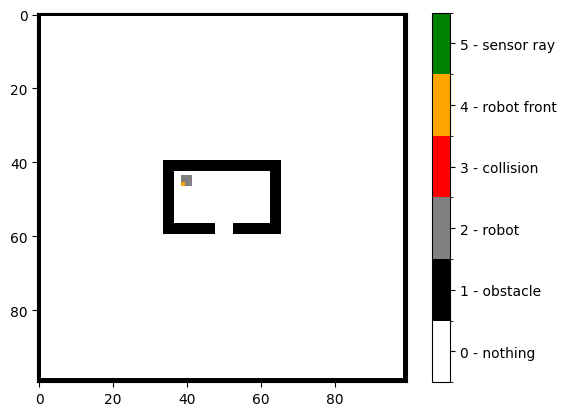


Statistiques:
	 translations      : 0.7365269461077845
	 rotations         : 0.49339590303872327
	 couverture        : 0.0133
	 position initiale : ( 48.5 , 48.5 , 0 )
	 position finale   : ( 39.58724445811089 , 44.25242374418788 , -2296.494166137523 )

New Fitness: 0.3731275684205811


In [14]:
# initial conditions

x_init = arena_size // 2 - particle_box / 2
y_init = arena_size // 2 - particle_box / 2
theta_init = 0

display_trace = True
display_arena = False

init()  # perform only once
create_arena_walls()
create_wall_2()

print("besteverFitness", besteverFitness)
print("besteverParams", besteverParams)

weights = besteverParams
retValues = simulate(x_init, y_init, theta_init, my_controller_NN_4sensors)
show_trace()
show_arena()

print()
print("Statistiques:")
print(
    "\t translations      :", retValues["translations"]
)  # Somme des valeurs absolues de translations. valeurs normalisées entre 0 et 1.
print(
    "\t rotations         :", retValues["rotations"]
)  # Somme des valeurs absolues de rotations. Valeur normalisée entre 0 et 1.
print(
    "\t couverture        :", retValues["coverage"]
)  # taux de couverture. Valeur normalisée entre 0 et 1 (arène entièrement couverte).
print(
    "\t position initiale : (", x_init, ",", y_init, ",", theta_init, ")"
)  # init: x,y,\theta
print(
    "\t position finale   : (",
    retValues["x_pos_end"],
    ",",
    retValues["y_pos_end"],
    ",",
    retValues["theta_end"],
    ")",
)  # final: init: x,y,\theta
print()
print(f"New Fitness: {retValues['translations'] * (1 - retValues['rotations'])}")

**ANSWER:**

With the agent trained with `create_wall_2(-20)` the agent has a bad fitness (~0.08) when evaluated on an environment created with `create_wall_2()` (It stays stuck in the box).


=-=-=-=-=
=-=-=-=-= Robot with CMA-ES
=-=-=-=-=
(5_w,10)-aCMA-ES (mu_w=3.2,w_1=45%) in dimension 10 (seed=1057382, Thu Mar 19 17:48:34 2026)
0 : -0.05248449681675245
1 : -0.0
2 : -0.2905396884832388
3 : -0.0
4 : -0.018718184816989197
5 : -0.0650952741536855
6 : -0.0221143489490076
7 : -0.04082434108810326
8 : -0.025912616019961924
9 : -0.2096489000035734
Iterat #Fevals   function value  axis ratio  sigma  min&max std  t[m:s]
    1     10 -2.905396884832388e-01 1.0e+00 8.93e-01  9e-01  9e-01 0:00.8
10 : -0.0
11 : -0.0
12 : -0.0
13 : -0.013885836961607965
14 : -0.0
15 : -0.0
16 : -0.0
17 : -0.28913464189894683
18 : -0.016002135976565114
19 : -0.0
    2     20 -2.891346418989468e-01 1.1e+00 8.68e-01  8e-01  9e-01 0:01.4
20 : -0.11548531461560639
21 : -0.10001803456826798
22 : -0.07975462776316734
23 : -0.12181415289317578
24 : -0.014233046838722101
25 : -1.74061642984779e-05
26 : -0.07773515609045228
27 : -0.0
28 : -0.020601260046740514
29 : -0.06558931364989307
    3     30 -1.218141528

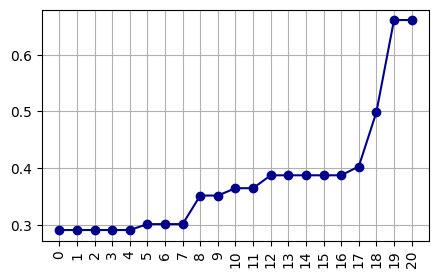

besteverFitness -0.6608700774262639
besteverParams [ 8.86079943e-02  3.43969820e+00 -4.34295789e+00  7.84780714e-01
 -2.94384082e-01 -1.07239385e+00  2.61685107e+00  1.41668300e+00
 -3.71635086e-05 -2.05385610e+00]
210 : -0.6608700774262639
-0.6608700774262639
# Final state


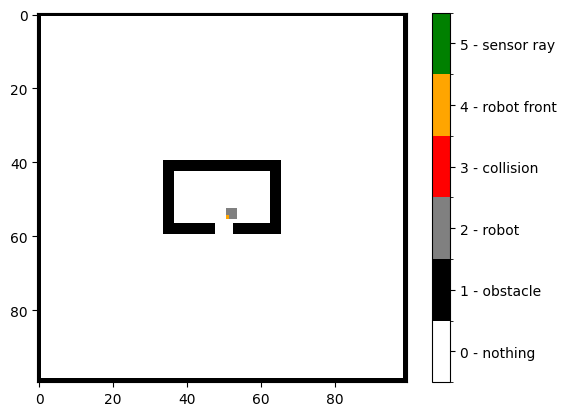

# Trajectory


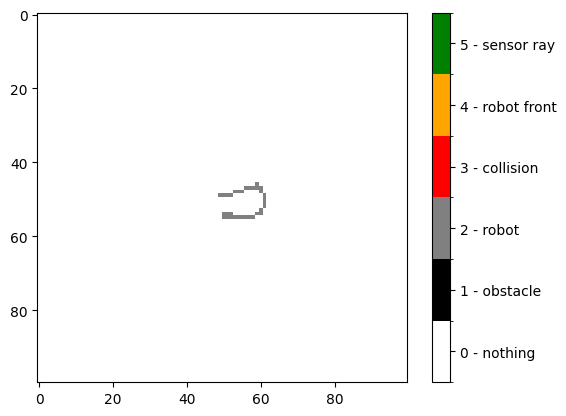

Terminé.


In [15]:
display_arena = False  # step-by-step display.
verbose_minimal_progress = (
    False  # suggested: True -- useful. Tune gap_between_... to limit the nb of messages
)
display_trace = False

# experimental settings

arena_size = 100
max_translation_per_step = 1.0  # >0. pixel per move.
max_rotation_per_step = 10.0  # >0, in degrees
max_iterations = 501  # nb of simulator iterations for evaluating one robot
max_iterations_evolve = 201  # nb of evolution iterations

# initial conditions

x_init = arena_size // 2 - particle_box / 2
y_init = arena_size // 2 - particle_box / 2
theta_init = 0

init()  # perform only once
create_arena_walls()
create_wall_2()

print("\n=-=-=-=-=\n=-=-=-=-= Robot with CMA-ES\n=-=-=-=-=")

eval = 0
besteverFitness, besteverParams = launch_cmaes(
    dim=10,
    display=True,  # Note
    ma_func=my_fitness_func_for_cmaes,
    max_evaluations=max_iterations_evolve,
)

print("besteverFitness", besteverFitness)
print("besteverParams", besteverParams)

retValues = my_fitness_func_for_cmaes(besteverParams)

print(retValues)
print("# Final state")
show_arena()
print("# Trajectory")
show_trace()
print("Terminé.")

**ANSWER:**

However when we train the agent with CMAES on the new starting conditions with `create_wall_2()` it learns the environment and obtains a better fitness score (~0.55 but depends on run) by escaping the box (sometimes).


=-=-=-=-=
=-=-=-=-= Robot with CMA-ES
=-=-=-=-=
(5_w,10)-aCMA-ES (mu_w=3.2,w_1=45%) in dimension 10 (seed=1021537, Thu Mar 19 17:54:37 2026)
0 : -0.0
1 : -0.07861843853373028
2 : -0.00795463884239413
3 : -0.0
4 : -0.0
5 : -0.0
6 : -0.1324633586996858
7 : -0.0
8 : -0.022546442091482814
9 : -0.05822916536867693
Iterat #Fevals   function value  axis ratio  sigma  min&max std  t[m:s]
    1     10 -1.324633586996858e-01 1.0e+00 9.26e-01  9e-01  9e-01 0:01.3
10 : -0.013082666996184808
11 : -0.007676390048661268
12 : -0.027626566084298268
13 : -0.009050805999298516
14 : -3.375298914580231e-05
15 : -0.024548683394057323
16 : -0.011773161046793074
17 : -0.028158677682291425
18 : -0.008815333311909599
19 : -0.022830296140259963
    2     20 -2.815867768229142e-02 1.1e+00 8.95e-01  9e-01  9e-01 0:02.9
20 : -0.412088740350764
21 : -0.316721805674966
22 : -0.02913404781864823
23 : -0.24325653939661981
24 : -0.029932129210822694
25 : -0.0
26 : -0.006186480986632848
27 : -0.012867319448239342
28 : -

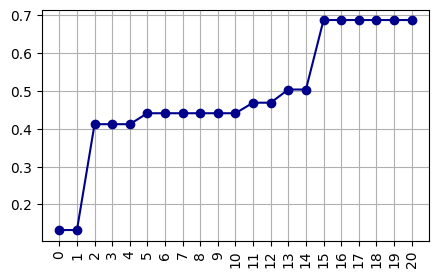

besteverFitness -0.687274314893664
besteverParams [ 0.40928501 -0.12350842  0.25577796  1.61958367  0.22451277 -2.41321927
 -0.76060438  0.67085652  1.98739222  0.66192899]
210 : -0.687274314893664
-0.687274314893664
# Final state


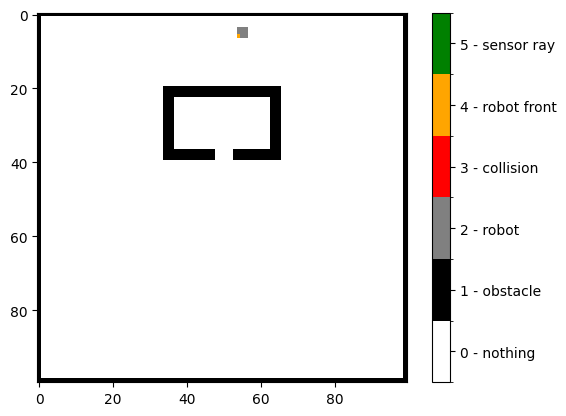

# Trajectory


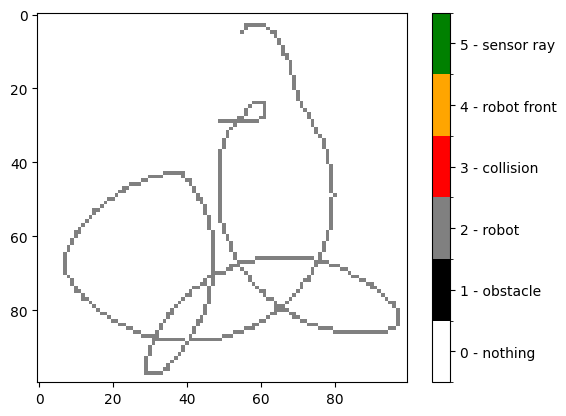

Terminé.
--- In Box ---
211 : -0.6861961230247826
-0.6861961230247826
# Final state


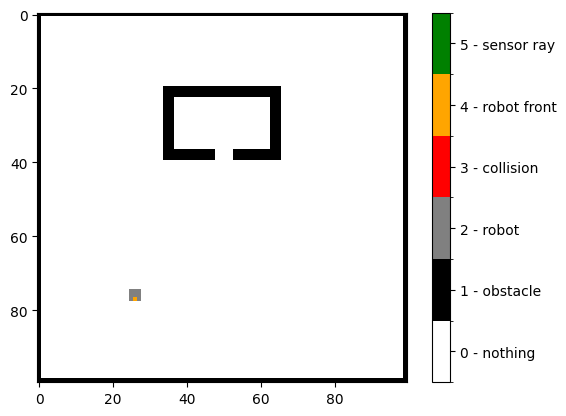

# Trajectory


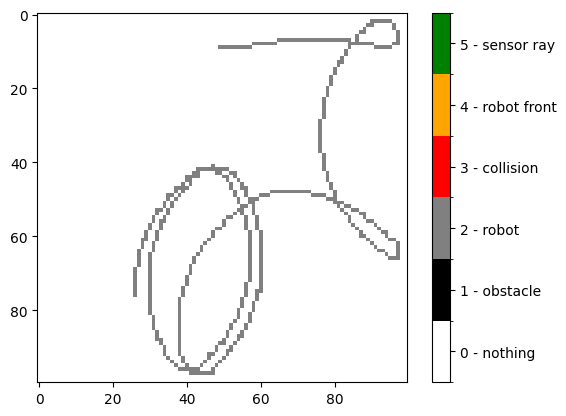

Terminé.


In [23]:
x_init = arena_size // 2 - particle_box / 2
y_init = arena_size // 2 - particle_box / 2
theta_init = 0


def launch_cmaes_w_random(dim, display, ma_func, max_evaluations):
    # !!!!!! !!!!!! !!!!!! !!!!!! !!!!!! A COMPLETER !!!!!! !!!!!! !!!!!! !!!!!! !!!!!!
    es = cma.CMAEvolutionStrategy(
        x0=np.random.uniform(-1, 1, dim),
        sigma0=1,
        inopts={"maxfevals": max_evaluations},
    )

    data = []
    while not es.stop():
        solutions = es.ask()
        es.tell(solutions, [ma_func(s) for s in solutions])
        es.disp()
        data.append(-es.result.fbest)

    if display:
        plot_data(data)
    # !!!!!! !!!!!! !!!!!! !!!!!! !!!!!! A COMPLETER !!!!!! !!!!!! !!!!!! !!!!!! !!!!!!
    return es.result.fbest, es.result.xbest


def my_fitness_func_for_cmaes(params):
    global x_init, y_init, theta_init, weights, eval
    weights = params
    retValues = simulate(x_init, y_init, theta_init, my_controller_NN_4sensors)
    retValues2 = simulate(x_init, y_init - 20, theta_init, my_controller_NN_4sensors)
    # !!!!!! !!!!!! !!!!!! !!!!!! !!!!!! A COMPLETER !!!!!! !!!!!! !!!!!! !!!!!! !!!!!!
    # !!!!!! !!!!!! !!!!!! !!!!!! !!!!!! A COMPLETER !!!!!! !!!!!! !!!!!! !!!!!! !!!!!!
    fitness = -0.5 * (
        retValues["translations"] * (1 - retValues["rotations"])
        + retValues2["translations"] * (1 - retValues2["rotations"])
    )
    # !!!!!! !!!!!! !!!!!! !!!!!! !!!!!! A COMPLETER !!!!!! !!!!!! !!!!!! !!!!!! !!!!!!
    # !!!!!! !!!!!! !!!!!! !!!!!! !!!!!! A COMPLETER !!!!!! !!!!!! !!!!!! !!!!!! !!!!!!
    if display_trace == True:
        show_trace()
    print(eval, ":", fitness)
    eval += 1
    return fitness


display_arena = False  # step-by-step display.
verbose_minimal_progress = (
    False  # suggested: True -- useful. Tune gap_between_... to limit the nb of messages
)
display_trace = False

# experimental settings

arena_size = 100
max_translation_per_step = 1.0  # >0. pixel per move.
max_rotation_per_step = 10.0  # >0, in degrees
max_iterations = 501  # nb of simulator iterations for evaluating one robot
max_iterations_evolve = 201  # nb of evolution iterations

# initial conditions


init()  # perform only once
create_arena_walls()
create_wall_2(-20)

print("\n=-=-=-=-=\n=-=-=-=-= Robot with CMA-ES\n=-=-=-=-=")

eval = 0
besteverFitness, besteverParams = launch_cmaes_w_random(
    dim=10,
    display=True,  # Note
    ma_func=my_fitness_func_for_cmaes,
    max_evaluations=max_iterations_evolve,
)

print("besteverFitness", besteverFitness)
print("besteverParams", besteverParams)

y_init = arena_size // 2 - particle_box / 2
retValues = my_fitness_func_for_cmaes(besteverParams)

print(retValues)
print("# Final state")
show_arena()
print("# Trajectory")
show_trace()
print("Terminé.")

print("--- In Box ---")

y_init = arena_size // 2 - particle_box / 2 - 20
retValues = my_fitness_func_for_cmaes(besteverParams)

print(retValues)
print("# Final state")
show_arena()
print("# Trajectory")
show_trace()
print("Terminé.")

y_init = arena_size // 2 - particle_box

**ANSWER:**

Initially we trained with a function that would randomly choose between starting in the box or not for each generation. training with random starting point using CMAES does not seem to work as we would expect. The robot remains stuck in the box when it starts there. Since CMAES assunes stationnary objective function, it probably not that well suited for a randomly changing objective function.

After we switched to doing a average of performance from inside the box and from outside and the results were much better (sometimes).

---
---
---

# <font color="orange">Partie 5. Fonctions objectifs et tâches</font>

A partir de cet exercice, vous pouvez augmentez (si vous le souhaitez) le budget d'évaluations utilisé. Pour cet exercice, on utilisera *create_wall_1* pour construire l'environnement initial. La position initiale du robot sera au centre de l'arène et son orientation sera de zéro (comme au début).

<font color="red">EXERCICES :</font>

- Vous remarquerez que la fonction simulation retourne un score de couverture. Avec CMAES, optimisez la politique pour maximiser ce score de couverture en l'utilisant comme valeur de fitness.

- Le score de couverture est une bonne mesure de la qualité d'une stratégie existante, mais pas forcément un bon guide pour l'optimisation. Ecrivez une fonction maximisant la couverture, c'est-à-dire qui ne contiendra pas forcément le score de couverture, mais aussi d'autres éléments pouvant guider l'optimisation, combiné ou non avec le score de couverture. Vous comparerez avec les résultats obtenus avec le score de couverture originel et ceux obtenus avec votre fonction fitness. Vous utiliserez le score de couverture pour tracer la performance des best-ever au cours de l'évolution dans les deux cas, afin que les résultats soient interprétables.




=-=-=-=-=
=-=-=-=-= Robot with CMA-ES
=-=-=-=-=
(5_w,10)-aCMA-ES (mu_w=3.2,w_1=45%) in dimension 10 (seed=1054944, Thu Mar 19 17:49:21 2026)
0 : -0.0229
1 : -0.0034
2 : -0.0024
3 : -0.0138
4 : -0.0026
5 : -0.0034
6 : -0.0034
7 : -0.0024
8 : -0.0034
9 : -0.0161
Iterat #Fevals   function value  axis ratio  sigma  min&max std  t[m:s]
    1     10 -2.290000000000000e-02 1.0e+00 9.65e-01  9e-01  1e+00 0:00.6
10 : -0.0034
11 : -0.0022
12 : -0.021
13 : -0.0034
14 : -0.0034
15 : -0.0034
16 : -0.0337
17 : -0.0034
18 : -0.0034
19 : -0.0032
    2     20 -3.370000000000000e-02 1.2e+00 9.15e-01  9e-01  9e-01 0:01.2
20 : -0.0034
21 : -0.0034
22 : -0.0036
23 : -0.0138
24 : -0.0279
25 : -0.0302
26 : -0.0014
27 : -0.0008
28 : -0.047
29 : -0.0034
    3     30 -4.700000000000000e-02 1.2e+00 8.73e-01  8e-01  9e-01 0:01.9
30 : -0.0141
31 : -0.0454
32 : -0.0471
33 : -0.0363
34 : -0.0138
35 : -0.0015
36 : -0.0023
37 : -0.0016
38 : -0.0034
39 : -0.0034
40 : -0.0314
41 : -0.0034
42 : -0.0034
43 : -0.0034
44 :

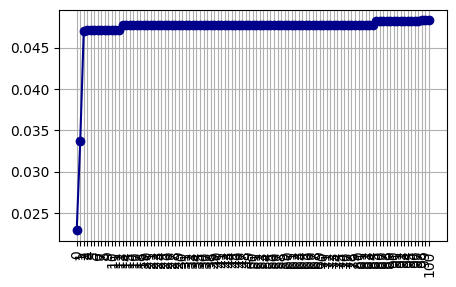

besteverFitness -0.0483
besteverParams [ 2.76280535  0.21625582 -2.27706289  2.78262914  6.28845366 -3.62047717
  4.25300634  2.67835032 -4.05664455  0.83209454]
1010 : -0.0483
-0.0483
# Final state


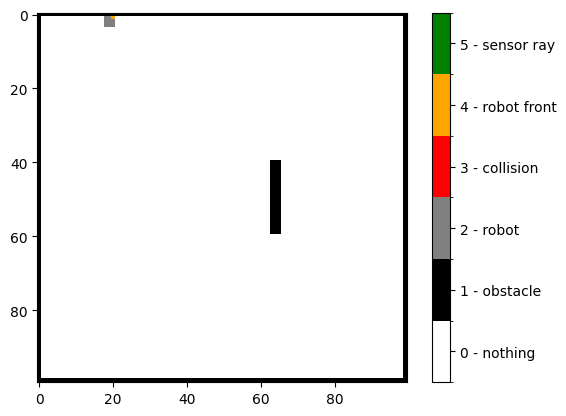

# Trajectory


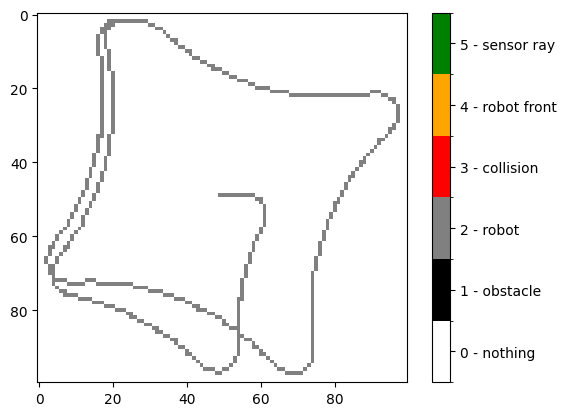

Terminé.


In [17]:
def my_fitness_func_for_cmaes_coverage(params):
    global x_init, y_init, theta_init, weights, eval
    weights = params
    retValues = simulate(x_init, y_init, theta_init, my_controller_NN_4sensors)
    # !!!!!! !!!!!! !!!!!! !!!!!! !!!!!! A COMPLETER !!!!!! !!!!!! !!!!!! !!!!!! !!!!!!
    # !!!!!! !!!!!! !!!!!! !!!!!! !!!!!! A COMPLETER !!!!!! !!!!!! !!!!!! !!!!!! !!!!!!
    fitness = -retValues["coverage"]
    # !!!!!! !!!!!! !!!!!! !!!!!! !!!!!! A COMPLETER !!!!!! !!!!!! !!!!!! !!!!!! !!!!!!
    # !!!!!! !!!!!! !!!!!! !!!!!! !!!!!! A COMPLETER !!!!!! !!!!!! !!!!!! !!!!!! !!!!!!
    if display_trace == True:
        show_trace()
    print(eval, ":", fitness)
    eval += 1
    return fitness


# display debug options

display_arena = False  # step-by-step display.
verbose_minimal_progress = (
    False  # suggested: True -- useful. Tune gap_between_... to limit the nb of messages
)
display_trace = False

# experimental settings

arena_size = 100
max_translation_per_step = 1.0  # >0. pixel per move.
max_rotation_per_step = 10.0  # >0, in degrees
max_iterations = 501  # nb of simulator iterations for evaluating one robot
max_iterations_evolve = 1001  # 201  # nb of evolution iterations

# initial conditions

x_init = arena_size // 2 - particle_box / 2
y_init = arena_size // 2 - particle_box / 2
theta_init = 0

init()  # perform only once
create_arena_walls()
create_wall_1()

print("\n=-=-=-=-=\n=-=-=-=-= Robot with CMA-ES\n=-=-=-=-=")

eval = 0
besteverFitness, besteverParams = launch_cmaes(
    dim=10,
    display=True,  # Note
    ma_func=my_fitness_func_for_cmaes_coverage,
    max_evaluations=max_iterations_evolve,
)

print("besteverFitness", besteverFitness)
print("besteverParams", besteverParams)

retValues = my_fitness_func_for_cmaes_coverage(besteverParams)

print(retValues)
print("# Final state")
show_arena()
print("# Trajectory")
show_trace()
print("Terminé.")



=-=-=-=-=
=-=-=-=-= Robot with CMA-ES
=-=-=-=-=
(5_w,10)-aCMA-ES (mu_w=3.2,w_1=45%) in dimension 10 (seed=994716, Thu Mar 19 17:50:20 2026)
0 : -0.0034
1 : -0.0014
2 : -0.0021
3 : -0.0034
4 : -0.0021
5 : -0.0034
6 : -0.0009
7 : -0.0034
8 : -0.0028
9 : -0.004658560860607689
Iterat #Fevals   function value  axis ratio  sigma  min&max std  t[m:s]
    1     10 -4.658560860607689e-03 1.0e+00 9.67e-01  9e-01  1e+00 0:00.7
10 : -0.0034
11 : -0.07391975971055453
12 : -0.0034
13 : -0.0029
14 : -0.0034
15 : -0.044275976324248484
16 : -0.0034
17 : -0.0039415048590991895
18 : -0.0034
19 : -0.017209621188204457
    2     20 -7.391975971055453e-02 1.2e+00 9.93e-01  1e+00  1e+00 0:01.4
20 : -0.0034
21 : -0.0006
22 : -0.0153
23 : -0.07342152516989897
24 : -0.06297715503923355
25 : -0.0034
26 : -0.0034
27 : -0.0034
28 : -0.0022593998689374125
29 : -0.0034
    3     30 -7.342152516989897e-02 1.3e+00 9.67e-01  9e-01  1e+00 0:02.0
30 : -0.0008
31 : -0.0034
32 : -0.060480583094856016
33 : -0.0885671814170

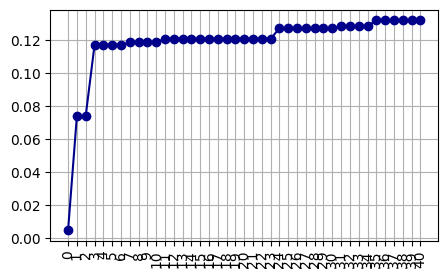

besteverFitness -0.1321112220762311
besteverParams [-2.30374888  1.3570674   1.77561657  0.78762813  1.51576586 -1.70656995
  1.91858819  0.27266322  0.0603557  -0.59032402]
410 : -0.1321112220762311
-0.1321112220762311
# Final state


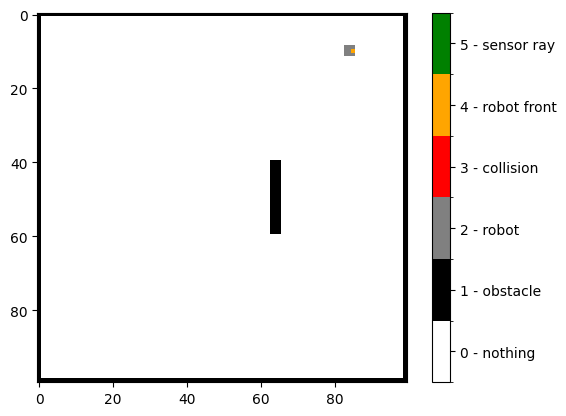

# Trajectory


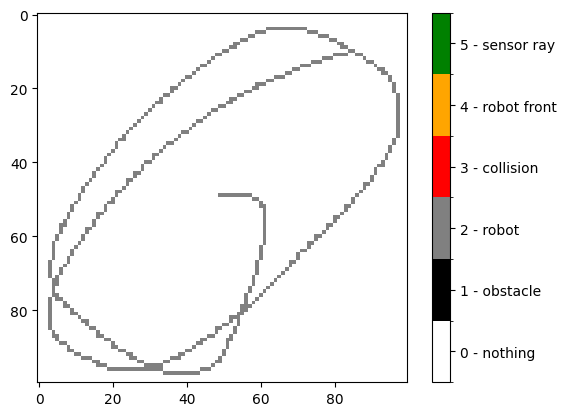

Terminé.


In [18]:
llambda = 0.1


def my_fitness_func_for_cmaes_coverage2(params):
    global x_init, y_init, theta_init, weights, eval, llambda
    weights = params
    retValues = simulate(x_init, y_init, theta_init, my_controller_NN_4sensors)
    # !!!!!! !!!!!! !!!!!! !!!!!! !!!!!! A COMPLETER !!!!!! !!!!!! !!!!!! !!!!!! !!!!!!
    # !!!!!! !!!!!! !!!!!! !!!!!! !!!!!! A COMPLETER !!!!!! !!!!!! !!!!!! !!!!!! !!!!!!
    fitness = -retValues["coverage"] - llambda * retValues["translations"] * (
        1 - retValues["rotations"]
    )
    # !!!!!! !!!!!! !!!!!! !!!!!! !!!!!! A COMPLETER !!!!!! !!!!!! !!!!!! !!!!!! !!!!!!
    # !!!!!! !!!!!! !!!!!! !!!!!! !!!!!! A COMPLETER !!!!!! !!!!!! !!!!!! !!!!!! !!!!!!
    if display_trace == True:
        show_trace()
    print(eval, ":", fitness)
    eval += 1
    return fitness


# display debug options

display_arena = False  # step-by-step display.
verbose_minimal_progress = (
    False  # suggested: True -- useful. Tune gap_between_... to limit the nb of messages
)
display_trace = False

# experimental settings

arena_size = 100
max_translation_per_step = 1.0  # >0. pixel per move.
max_rotation_per_step = 10.0  # >0, in degrees
max_iterations = 501  # nb of simulator iterations for evaluating one robot
max_iterations_evolve = 401  # 201  # nb of evolution iterations

# initial conditions

x_init = arena_size // 2 - particle_box / 2
y_init = arena_size // 2 - particle_box / 2
theta_init = 0

init()  # perform only once
create_arena_walls()
create_wall_1()

print("\n=-=-=-=-=\n=-=-=-=-= Robot with CMA-ES\n=-=-=-=-=")

eval = 0
besteverFitness, besteverParams = launch_cmaes(
    dim=10,
    display=True,  # Note
    ma_func=my_fitness_func_for_cmaes_coverage2,
    max_evaluations=max_iterations_evolve,
)

print("besteverFitness", besteverFitness)
print("besteverParams", besteverParams)

retValues = my_fitness_func_for_cmaes_coverage2(besteverParams)

print(retValues)
print("# Final state")
show_arena()
print("# Trajectory")
show_trace()
print("Terminé.")


**ANSWER:**

Using the original coverage variable discourages the agent from visiting the same pixel twice, but does nothing about its speed and rotation resulting in smaller circular motions, which doesn't necessarily match with coverage of the full space fast. We decided to modify the fitness function as `coverage` + $\lambda$ * `translation`*(1-`rotation`). Having the translation and rotations being part of the optimization problem encourages the robot to cover the space faster and more uniformly, `coverage` part discoraging robot to produce crossing trajectories - we can balance these two factors with regularization parameter $\lambda$

---
---
---

# <font color="orange">Partie 6. Architectures neuronales</font>

Nous allons maintenant modifier la structure de la politique en implémentant des architectures de réseaux de neurones artificiels classiques (mais relativement "légères"). A part la première question, il s'agit d'un exercice difficile à faire *uniquement* si vous avez terminé (et réussi) tout ce qui précède.

En particulier, la dernière question correspond à la mise en place d'une méthodologie rigoureuse de test. Par les temps de calcul qu'elle implique, elle *ne peut pas* être réalisée dans le temps de ce TP. Elle est énoncée ici à titre indicatif (ie. il ne s'agit pas d'un devoir à la maison).

<font color="red">EXERCICES :</font>

- Modifiez la structure de la politique, qui est actuellement une combinaison linéaire des entrées pondérées par des poids. Vous implémenterez un Perceptron simple (fonction d'activation non-linéaire)

- idem avec un perceptron multi-couche (nombre de noeuds à discretion, par exemple 3)

- Comparez ces architectures (y compris celle par défaut). Vous testerez sur les deux fonctions fitness utilisées précédemment: déplacement et couverture. Pour l'instant on se contentera d'un seul run par condition expérimentale (ie. tâche et architecture du réseau).

- idem avec un réseau Elman, c'est à dire avec des connexions récurrentes pour les noeuds de la couche cachée. Chaque noeud de la couche cachée projette sur tous les autres et sur lui-même.

- idem avec un réseau Jordan, c'est à dire avec deux sorties supplémentaires qui projettent sur deux entrées supplémentaires (ie. connexions récurrentes en réinjectant la valeur de certaines sorties produites à *t-1* en valeurs d'entrées à *t*)

- Comparez toutes ces architectures (y compris celle par défaut) avec plusieurs runs indépendant pour chaque conditions expérimentales (type de réseaux, tâches) en variant la position de départ dans un cercle de 4 unités ainsi que l'orientation à chaque évaluation (il sera peut-être nécessaire de ré-évaluer chaque individu pour avoir une bonne approximation de sa performance moyenne). Pour chaque condition expérimentale, vous pouvez vous contentez d'afficher les données brutes du best-ever pour chaque run fait (ou un boxplot si vous avez 11 runs par setup).


#
# (1+1)-ES 1/5th rule for maximising translation and minimasing rotation#
it = 0 , current_fit = 0.3631621244888867 , best_fit = 0.3631621244888867
it = 20 , current_fit = 0.43545538157389346 , best_fit = 0.43545538157389346
it = 40 , current_fit = 0.03705777911621959 , best_fit = 0.7342589095123002
it = 60 , current_fit = 0.7250600131013121 , best_fit = 0.7802335367508865
it = 80 , current_fit = 0.6051228307678079 , best_fit = 0.7844921020327665
it = 100 , current_fit = 0.7764163314317291 , best_fit = 0.7847452083801215
it = 120 , current_fit = 0.7805812069528051 , best_fit = 0.7896569091809907
it = 140 , current_fit = 0.7874442721548685 , best_fit = 0.789659119984009
it = 160 , current_fit = 0.7896589250217104 , best_fit = 0.789659119984009
it = 180 , current_fit = 0.7896592147321855 , best_fit = 0.7896593331215587
it = 200 , current_fit = 0.7895958269771439 , best_fit = 0.7896593615532486
Best fit 0.7896593615532486 found at iteration 196

Rejoue et affiche la meilleure solution
[

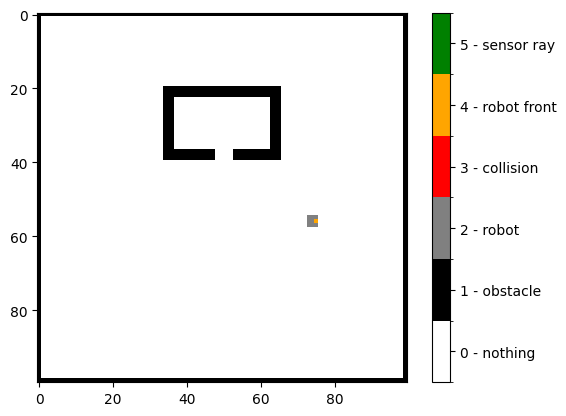

# Trajectory


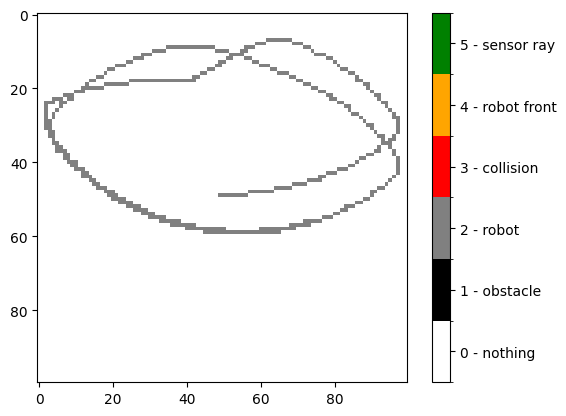

Terminé.


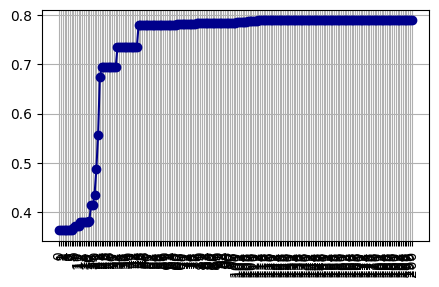

In [19]:
def my_controller_NN_4sensors_simple_perceptron(sensors):
    global weights
    translation = np.tanh(
        weights[0] * sensors[-2]
        + weights[1] * sensors[0]
        + weights[2] * sensors[2]
        + weights[3] * sensors[4]
        + weights[4]
    )
    rotation = np.tanh(
        weights[5] * sensors[-2]
        + weights[6] * sensors[0]
        + weights[7] * sensors[2]
        + weights[8] * sensors[4]
        + weights[9]
    )
    # print (sensors,translation,rotation,absolute_orientation)
    return translation, rotation


def launch_oneplusone_withOneFifthRule(
    individual, sigma_init, nbeval, display, ma_func
):
    # !!!!!! !!!!!! !!!!!! !!!!!! !!!!!! A COMPLETER !!!!!! !!!!!! !!!!!! !!!!!! !!!!!!
    sigma = sigma_init
    i = 0
    besteverFit = -float("inf")
    besteverIt = 0
    besteverSolution = individual
    data = []
    while i < nbeval:
        candidateSolution = np.random.randn(len(individual)) * sigma + besteverSolution
        fit = ma_func(candidateSolution)
        if fit >= besteverFit:
            besteverSolution = np.copy(candidateSolution)
            besteverFit = fit
            besteverIt = i
            sigma *= 2
        else:
            sigma *= 2 ** (-1 / 4)
        data.append(besteverFit)
        if display and i % (int(nbeval / 10)) == 0:
            print("it =", i, ", current_fit =", fit, ", best_fit =", besteverFit)
        i += 1
    print("Best fit", besteverFit, "found at iteration", besteverIt)
    # !!!!!! !!!!!! !!!!!! !!!!!! !!!!!! A COMPLETER !!!!!! !!!!!! !!!!!! !!!!!! !!!!!!
    return besteverIt, besteverFit, besteverSolution, data


def my_fitness_func_maximize(params):  # fitness function
    global x_init, y_init, theta_init, weights
    weights = params
    retValues = simulate(
        x_init, y_init, theta_init, my_controller_NN_4sensors_simple_perceptron
    )
    # !!!!!! !!!!!! !!!!!! !!!!!! !!!!!! A COMPLETER !!!!!! !!!!!! !!!!!! !!!!!! !!!!!!
    # !!!!!! !!!!!! !!!!!! !!!!!! !!!!!! A COMPLETER !!!!!! !!!!!! !!!!!! !!!!!! !!!!!!
    fitness = retValues["translations"] * (1 - retValues["rotations"])
    # !!!!!! !!!!!! !!!!!! !!!!!! !!!!!! A COMPLETER !!!!!! !!!!!! !!!!!! !!!!!! !!!!!!
    # !!!!!! !!!!!! !!!!!! !!!!!! !!!!!! A COMPLETER !!!!!! !!!!!! !!!!!! !!!!!! !!!!!!
    if display_trace == True:  # noqa: E712
        show_trace()
    return fitness


# Main

print("#\n# (1+1)-ES 1/5th rule for maximising translation and minimasing rotation#")

display_arena = False  # diplay step-by-step if True.
verbose_minimal_progress = (
    False  # suggested: True -- useful. Tune gap_between_... to limit the nb of messages
)
display_trace = False

init()

# clear_arena()
create_arena_walls()
create_wall_2(-20)

max_iterations = 501  # nb of simulation iterations for one robot
max_iterations_evolve = 201  # nb of evolution iterations

x_init = arena_size // 2 - particle_box / 2
y_init = arena_size // 2 - particle_box / 2
theta_init = 0

initial_solution = np.random.uniform(-1.0, 1.0, size=10).tolist()
besteverIt, besteverFit, besteverSolution, data = launch_oneplusone_withOneFifthRule(
    initial_solution,
    nbeval=max_iterations_evolve,
    sigma_init=0.0001,
    display=True,
    ma_func=my_fitness_func_maximize,
)

print("\nRejoue et affiche la meilleure solution")

weights = np.copy(besteverSolution).tolist()
print(weights)
retValues = simulate(x_init, y_init, theta_init, my_controller_NN_4sensors)

print(retValues)
print("# Final state")
show_arena()
print("# Trajectory")
show_trace()
print("Terminé.")


def plot_data(
    data, title=None, x_label=None, y_label=None, interval=1, y_min=None, y_max=None
):
    x_values = range(0, len(data), interval)
    y_values = data[::interval]
    x_ticks = range(len(data))[::interval]
    plt.figure(figsize=(5, 3))
    plt.plot(x_values, y_values, marker="o", linestyle="-", color="darkblue")
    if title is not None:
        plt.title(title)
    if x_label is not None:
        plt.xlabel(x_label)
    if y_label is not None:
        plt.ylabel(y_label)
    plt.grid(True)
    plt.xticks(x_ticks)
    plt.xticks(rotation=90)
    if y_min is not None and y_max is not None:
        plt.ylim(y_min, y_max)
    plt.show()


plot_data(data)


---
---
---

# <font color="orange">Fin du sujet.</font>

---
---
---
